# Week 3 — Linear Family Baselines on UCI Concrete Dataset

This notebook explains the results of the Linear Family baseline models for predicting concrete compressive strength.

**Important:** This is a **results explanation notebook**, not a training notebook.

The actual model training, hyperparameter tuning, and result generation are handled by the training script in `scripts/run_week03_linear.py`.

This notebook loads the saved results and explains them.


## 1. Task Objective

The goal of Week 3 is to implement machine learning baseline models for the UCI Concrete Compressive Strength dataset.

The assignment asks us to:

- understand how each selected model works,
- explain what the model minimizes,
- identify the main hyperparameters controlling model capacity,
- tune selected models fairly,
- evaluate the models using MAE, RMSE, R, and residual plots,
- analyze whether residuals are random or systematic.

For the Linear Family, the selected models are: OLS Linear Regression, Elastic Net, Bayesian Ridge, and Polynomial Ridge.


## 2. Dataset and Features

For Week 3, only the original Yeh-style input features are used.

The target variable is:

- Strength: concrete compressive strength in MPa

The input features are:

- Cement
- Slag
- FlyAsh
- Water
- Superplasticizer
- CoarseAggregate
- FineAggregate
- Age

Although the cleaned dataset contains engineered features from Week 2, those features are not used in this Week 3 baseline. This keeps the comparison closer to the original Yeh concrete dataset setup.


In [ ]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from IPython.display import display, Markdown, Image



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()

TABLES_DIR = PROJECT_ROOT / 'reports' / 'tables'
FIGURES_DIR = PROJECT_ROOT / 'reports' / 'figures'
PREDICTIONS_DIR = PROJECT_ROOT / 'results' / 'predictions'

METRICS_PATH = TABLES_DIR / 'week03_linear_metrics.csv'
BEST_PARAMS_PATH = TABLES_DIR / 'week03_linear_best_params.csv'
PREDICTIONS_PATH = PREDICTIONS_DIR / 'week03_linear_predictions.csv'

print('Project root:', PROJECT_ROOT)
print('Metrics file:', METRICS_PATH)
print('Best parameters file:', BEST_PARAMS_PATH)
print('Predictions file:', PREDICTIONS_PATH)


Project root: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear
Metrics file: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week03_linear_metrics.csv
Best parameters file: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week03_linear_best_params.csv
Predictions file: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/results/predictions/week03_linear_predictions.csv


In [4]:
def load_csv_if_exists(path, name):
    if path.exists():
        print(f'Loaded {name}: {path}')
        return pd.read_csv(path)
    else:
        display(Markdown(
            f"""
> **Missing file:** `{path}`
> This file is generated by the training script and is intentionally not pushed to GitHub.
> Please run the Week 3 script first to regenerate it.
            """
        ))
        return None


metrics_df = load_csv_if_exists(METRICS_PATH, 'metrics table')
best_params_df = load_csv_if_exists(BEST_PARAMS_PATH, 'best parameters table')
predictions_df = load_csv_if_exists(PREDICTIONS_PATH, 'predictions table')


Loaded metrics table: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week03_linear_metrics.csv
Loaded best parameters table: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/reports/tables/week03_linear_best_params.csv
Loaded predictions table: /Users/apple/Brijesh/DE/SoSe2026/Special Project/Da2De/S1_Linear/results/predictions/week03_linear_predictions.csv


## 3. Experimental Setup

The team agreed to use:

- **test_size = 0.20:** 80% of data for training, 20% for final evaluation
- **cv_folds = 3:** 3-fold cross-validation for hyperparameter tuning
- **random_state = 42:** Reproducible splits and random initialization

### Why test_size = 0.20?

A 20% test set is a common practical choice in machine learning. It keeps enough unseen data for final evaluation while still leaving 80% of the dataset for training. This is useful because the concrete dataset is not extremely large, and using 80% for training helps models learn more stable coefficients, especially for regularized and polynomial models.

### Why cv_folds = 3?

3-fold cross-validation is a practical compromise between reliability and computation time. For each hyperparameter combination, the model is trained three times on different validation folds. This is better than relying on one single validation split, but faster than 5-fold or 10-fold CV. Since the team is comparing different model families, using the same 3-fold CV setting across all groups makes the comparison fair and consistent.


## 4. Evaluation Metrics

The models are evaluated using:

- **MAE:** Mean Absolute Error (MPa). Average absolute prediction error in the same units as the target.
- **RMSE:** Root Mean Squared Error (MPa). Penalizes large errors more strongly than MAE.
- **R:** Pearson correlation coefficient between actual and predicted strength. Ranges from -1 to 1.
- **R²:** Coefficient of determination. Fraction of variance in the target explained by the model. Ranges from 0 to 1.

Higher values of R and R² are better. Lower values of MAE and RMSE are better.


## 5. Final Model Comparison

The following table is loaded from the saved results folder. It compares all four Linear Family models using MAE, RMSE, R, and R².


In [5]:
if metrics_df is not None:
    display(metrics_df.round(4))


,Model,MAE,RMSE,R,R2
0,OLS,8.7191,10.9432,0.7852,0.6165
1,Elastic Net,8.7267,10.9448,0.7851,0.6164
2,Bayesian Ridge,8.7464,10.9503,0.7849,0.6160
3,Polynomial Ridge,4.6864,6.5712,0.9283,0.8617


## 6. Best Model Based on RMSE


In [6]:
if metrics_df is not None and 'RMSE' in metrics_df.columns:
    sorted_results = metrics_df.sort_values('RMSE')
    best = sorted_results.iloc[0]
    worst = sorted_results.iloc[-1]

    display(Markdown(f"""
The best model by RMSE is: **{best['Model']}**

This model achieved:

- MAE: **{best['MAE']:.4f}** MPa
- RMSE: **{best['RMSE']:.4f}** MPa
- R: **{best['R']:.4f}**
- R²: **{best['R2']:.4f}**

RMSE is used for selecting the best model because it penalizes large prediction errors more strongly than MAE. In concrete strength prediction, large errors are practically important because they may lead to unsafe or incorrect design conclusions.

For comparison, the weakest model by RMSE is: **{worst['Model']}**

- MAE: **{worst['MAE']:.4f}** MPa
- RMSE: **{worst['RMSE']:.4f}** MPa
- R: **{worst['R']:.4f}**
- R²: **{worst['R2']:.4f}**
    """))



The best model by RMSE is: **Polynomial Ridge**

This model achieved:

- MAE: **4.6864** MPa
- RMSE: **6.5712** MPa
- R: **0.9283**
- R²: **0.8617**

RMSE is used for selecting the best model because it penalizes large prediction errors more strongly than MAE. In concrete strength prediction, large errors are practically important because they may lead to unsafe or incorrect design conclusions.

For comparison, the weakest model by RMSE is: **Bayesian Ridge**

- MAE: **8.7464** MPa
- RMSE: **10.9503** MPa
- R: **0.7849**
- R²: **0.6160**
    

## 7. Best Hyperparameters

The best hyperparameters shown below are loaded from the saved tuning results generated by the training script. This ensures the notebook explains the actual model results instead of repeating code or hard-coding values.


In [7]:
if best_params_df is not None:
    display(best_params_df)


,Model,Best parameters
0,OLS,NaN
1,Elastic Net,"{'model__alpha': 0.001, 'model__l1_ratio': 0.1}"
2,Bayesian Ridge,Default sklearn parameters
3,Polynomial Ridge,"{'model__alpha': 0.1, 'poly__degree': 3}"


## 8. Why These Parameter Ranges Were Used

### Model 1: OLS Linear Regression

OLS is the simplest baseline. It has no hyperparameters to tune—it directly minimizes the sum of squared residuals using all data.

### Model 2: Elastic Net

Elastic Net was tuned using:

- **alpha** from 0.001 to 100 (logarithmic scale)
- **l1_ratio** from 0.1 to 0.9 (different L1/L2 balances)

The reason for this range is practical:

- Very small alpha (0.001, 0.01) checks whether the model behaves close to ordinary linear regression without regularization.
- Medium alpha (0.1, 1) checks balanced regularization.
- Large alpha (10, 100) checks whether stronger shrinkage improves generalization and reduces overfitting.

The l1_ratio range checks different mixtures of L1 (Lasso) and L2 (Ridge) penalties. A ratio of 0.1 means mostly Ridge behavior, 0.5 means balanced, and 0.9 means mostly Lasso behavior.

### Model 3: Bayesian Ridge

Bayesian Ridge uses default sklearn parameters. The model internally estimates regularization strength during fitting, so explicit tuning is not necessary for this baseline.

### Model 4: Polynomial Ridge Regression

Polynomial Ridge was tuned using:

- **degree** from 1 to 3
- **Ridge alpha** from 0.01 to 100

Degree 1 represents simple Ridge regression. Degree 2 adds squared terms and pairwise interactions. Degree 3 adds more complex nonlinear interactions.

Higher degrees were not used because polynomial features increase very quickly:

- 8 original features at degree 1 gives 8 features
- 8 original features at degree 2 gives 44 polynomial features
- 8 original features at degree 3 gives 164 polynomial features

With very high polynomial degrees, the model can easily overfit and become uninterpretable.

Ridge alpha was tested from weak (0.01, 0.1) to strong (10, 100) regularization to control overfitting after polynomial feature expansion.


## 9. Actual vs Predicted Plots

The actual vs predicted plot shows how close the model predictions are to the true laboratory strength values.

A perfect model would place all points on the diagonal line. If points are far from the diagonal, the model has large prediction errors.


### Bayesian Ridge

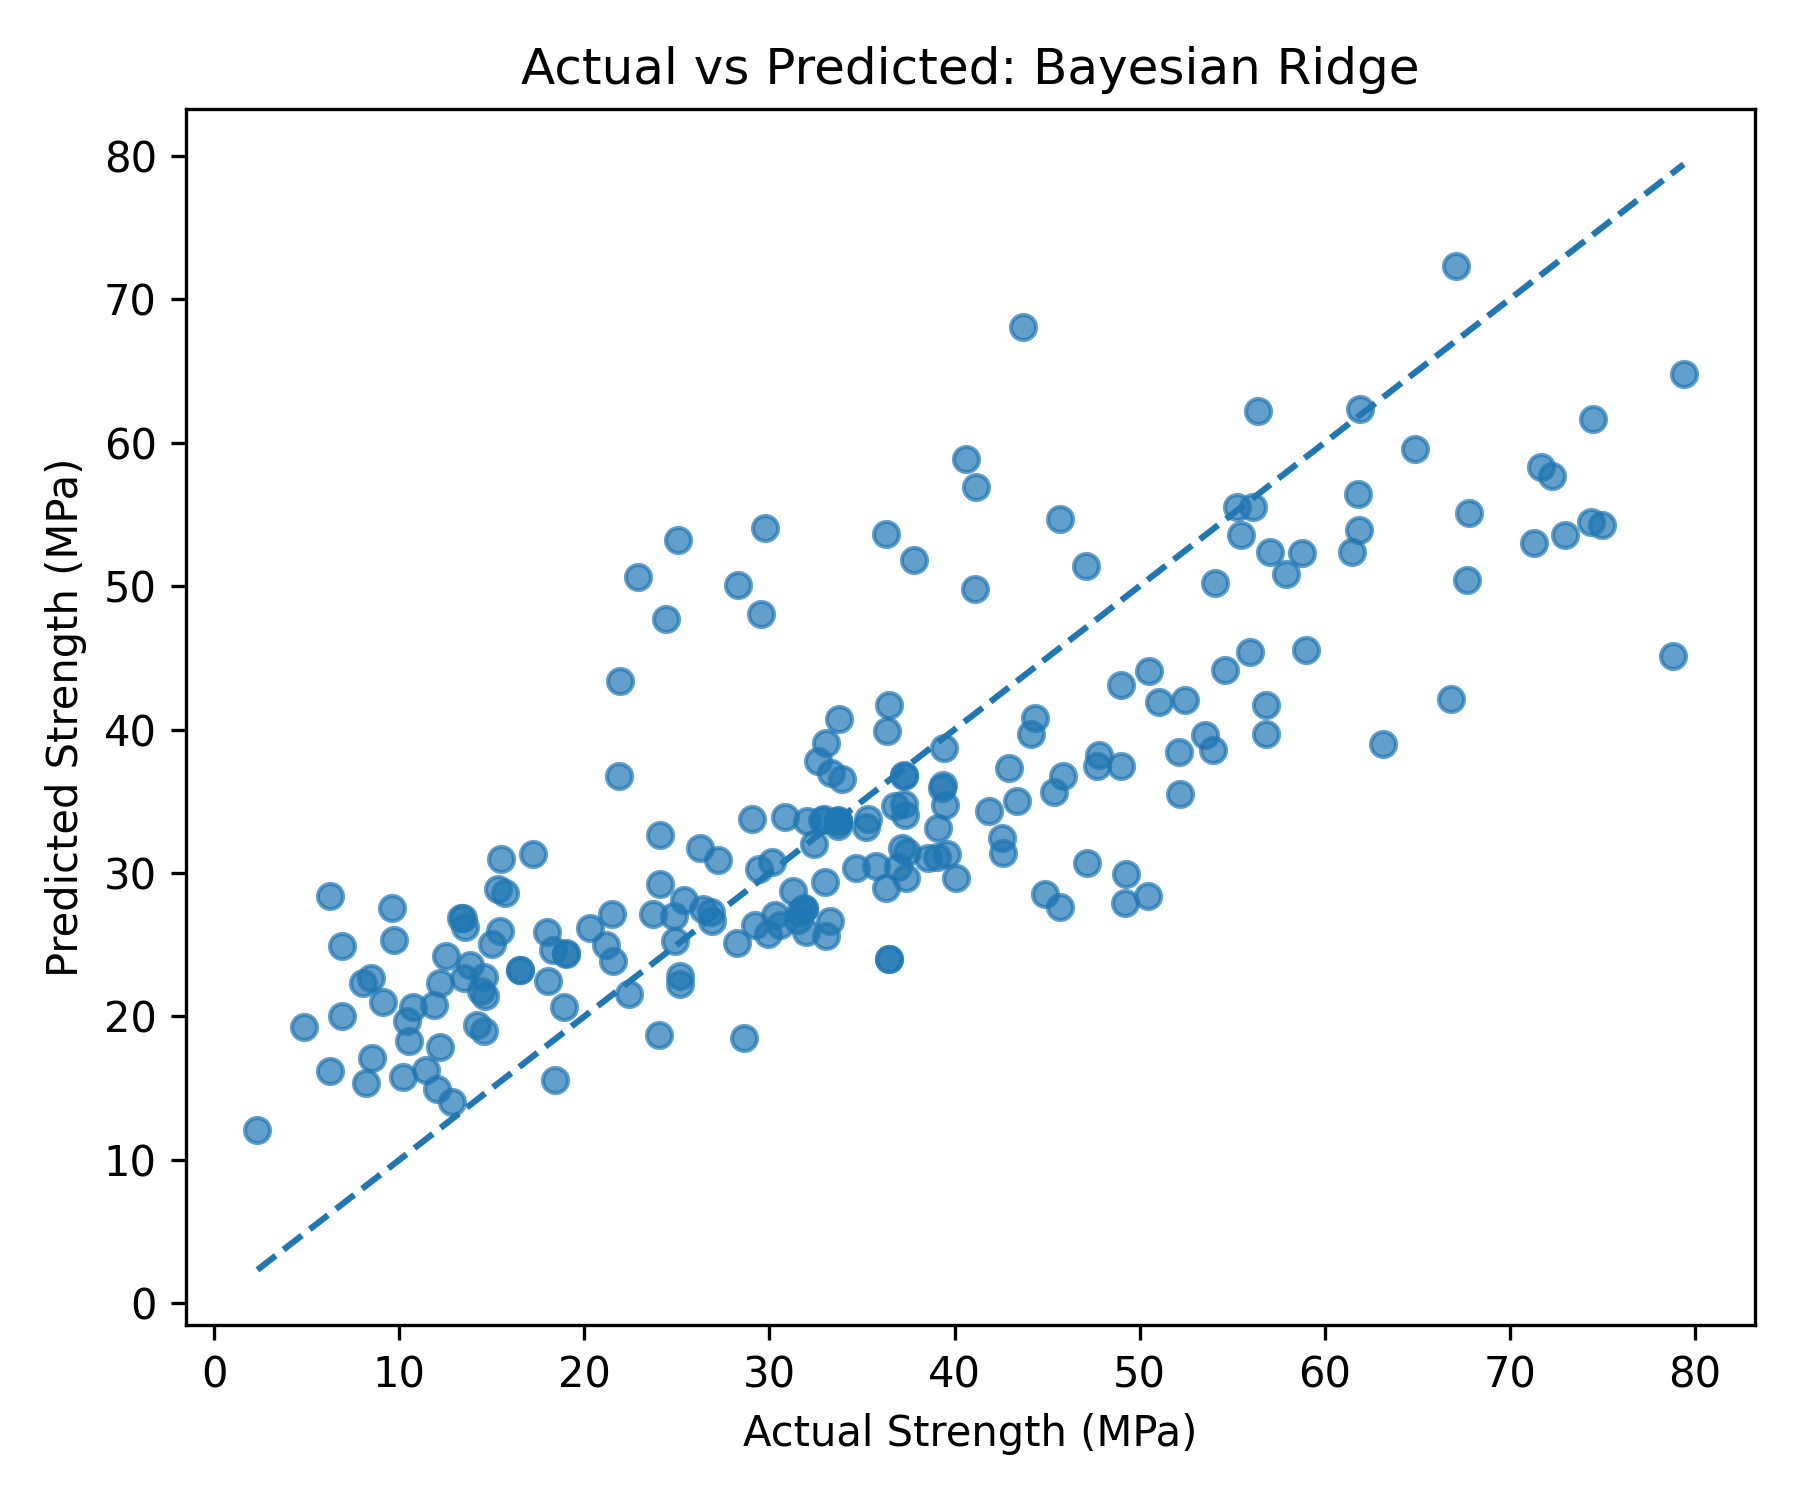

### Elastic Net

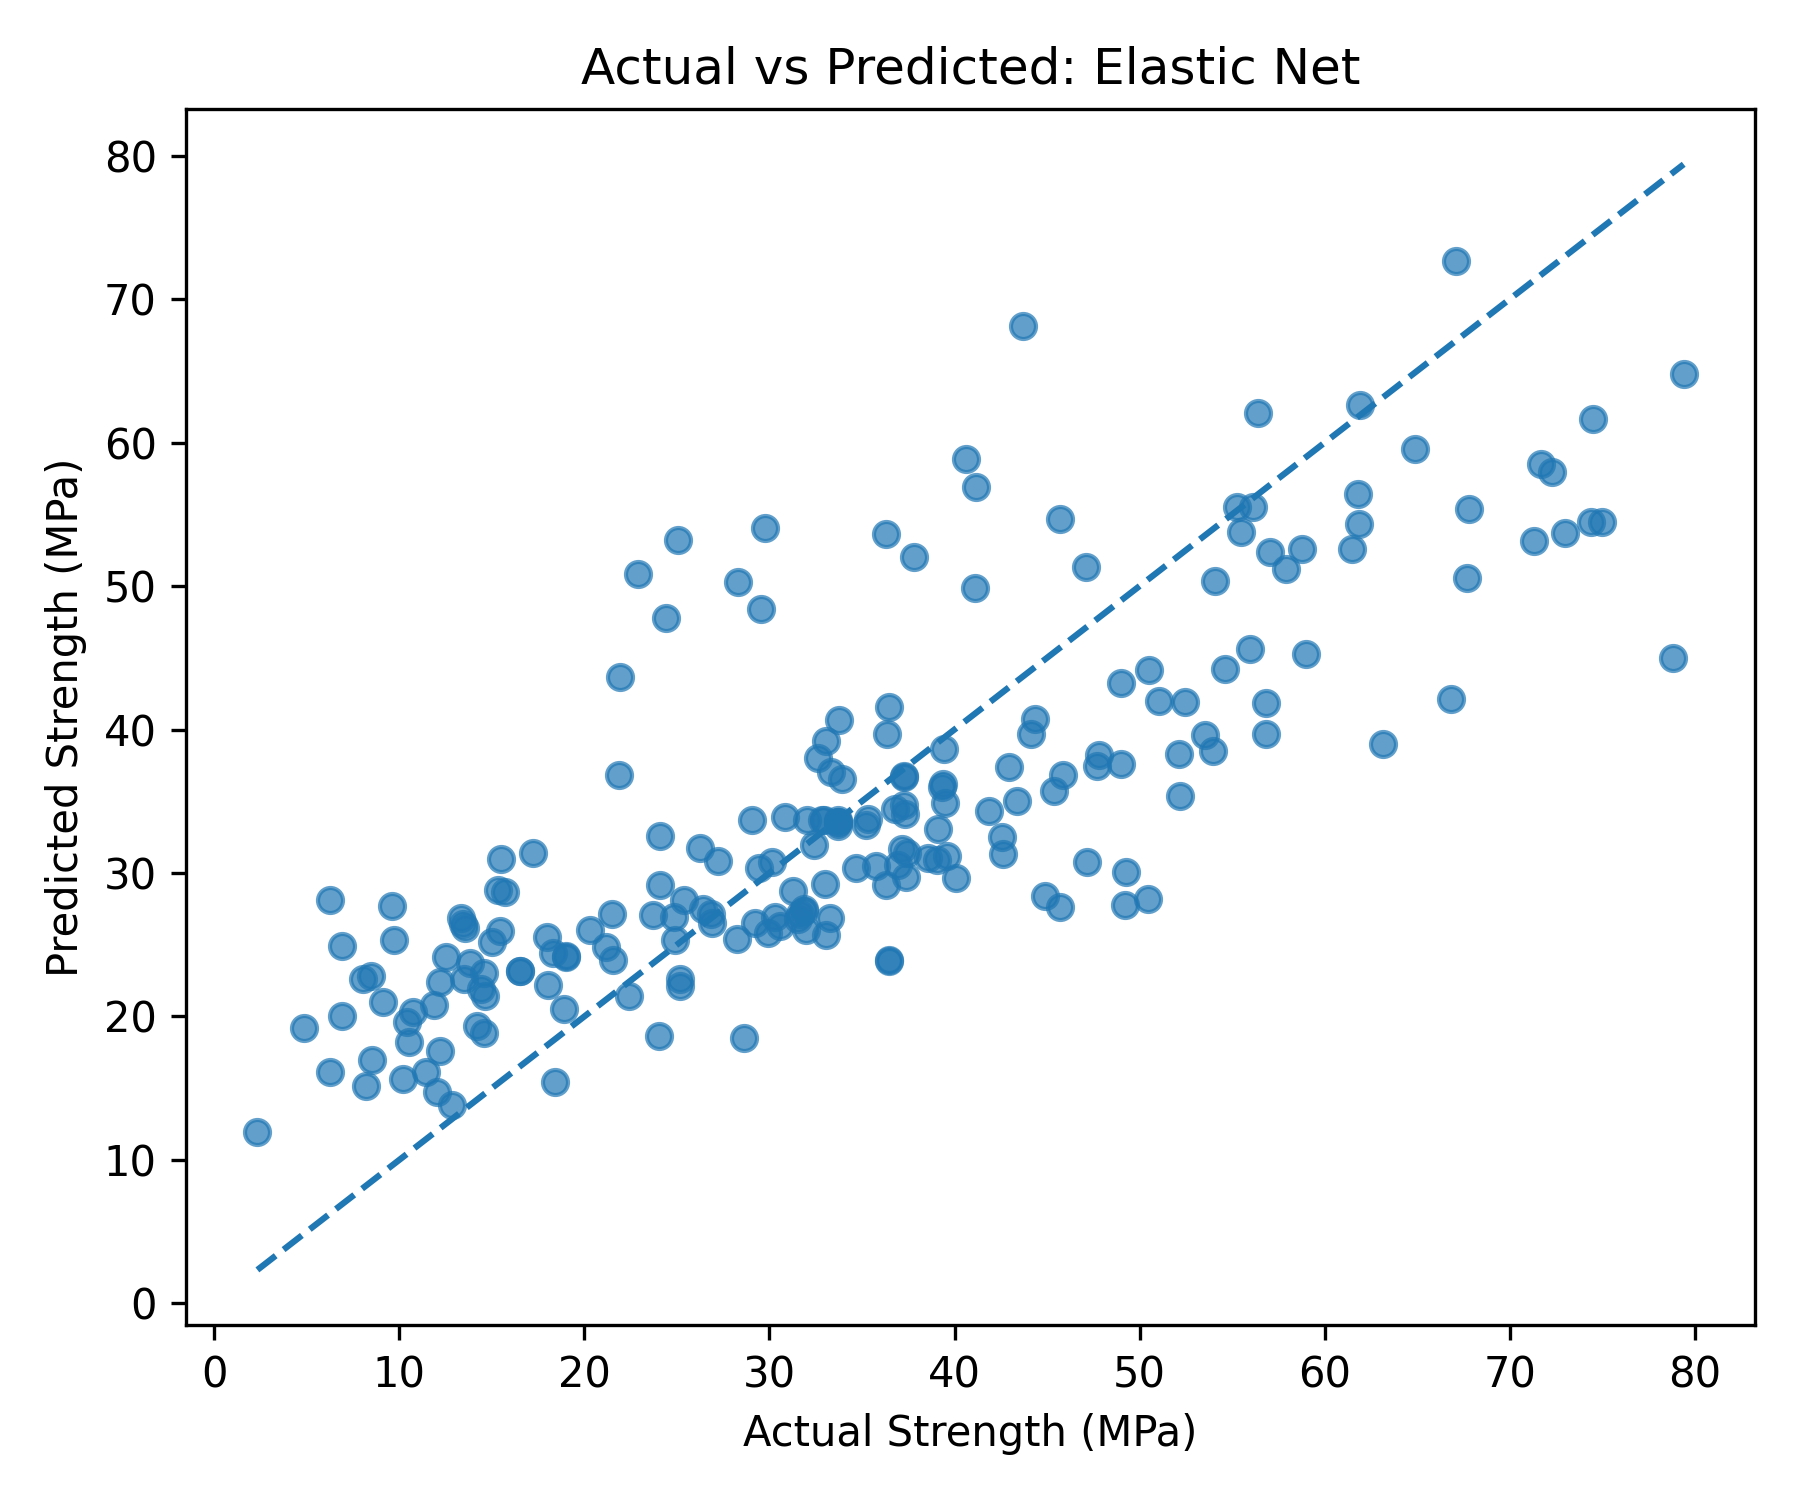

### Ols

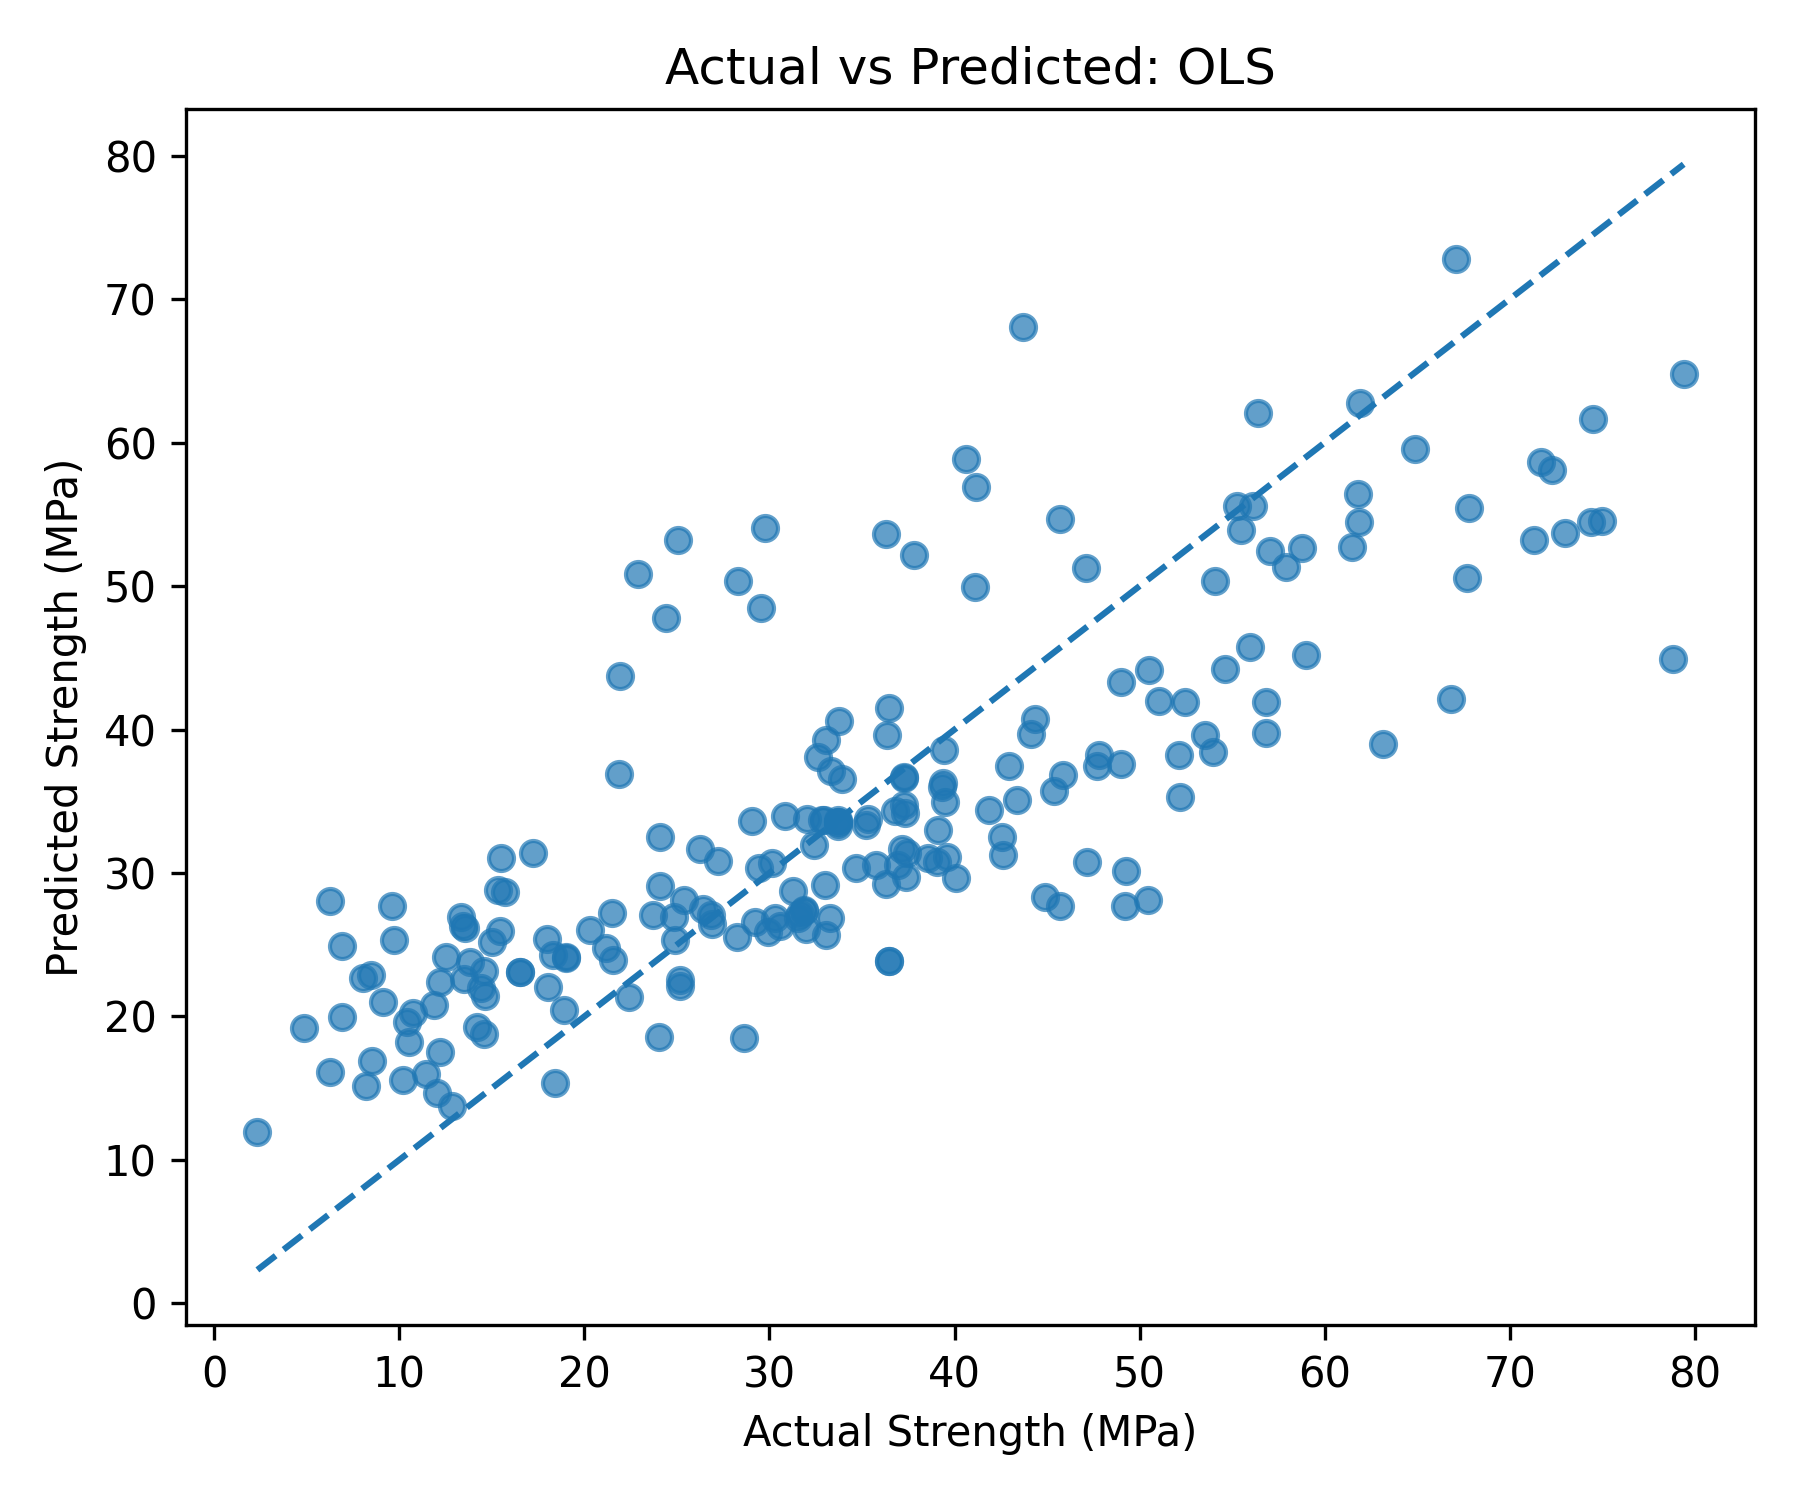

### Polynomial Ridge

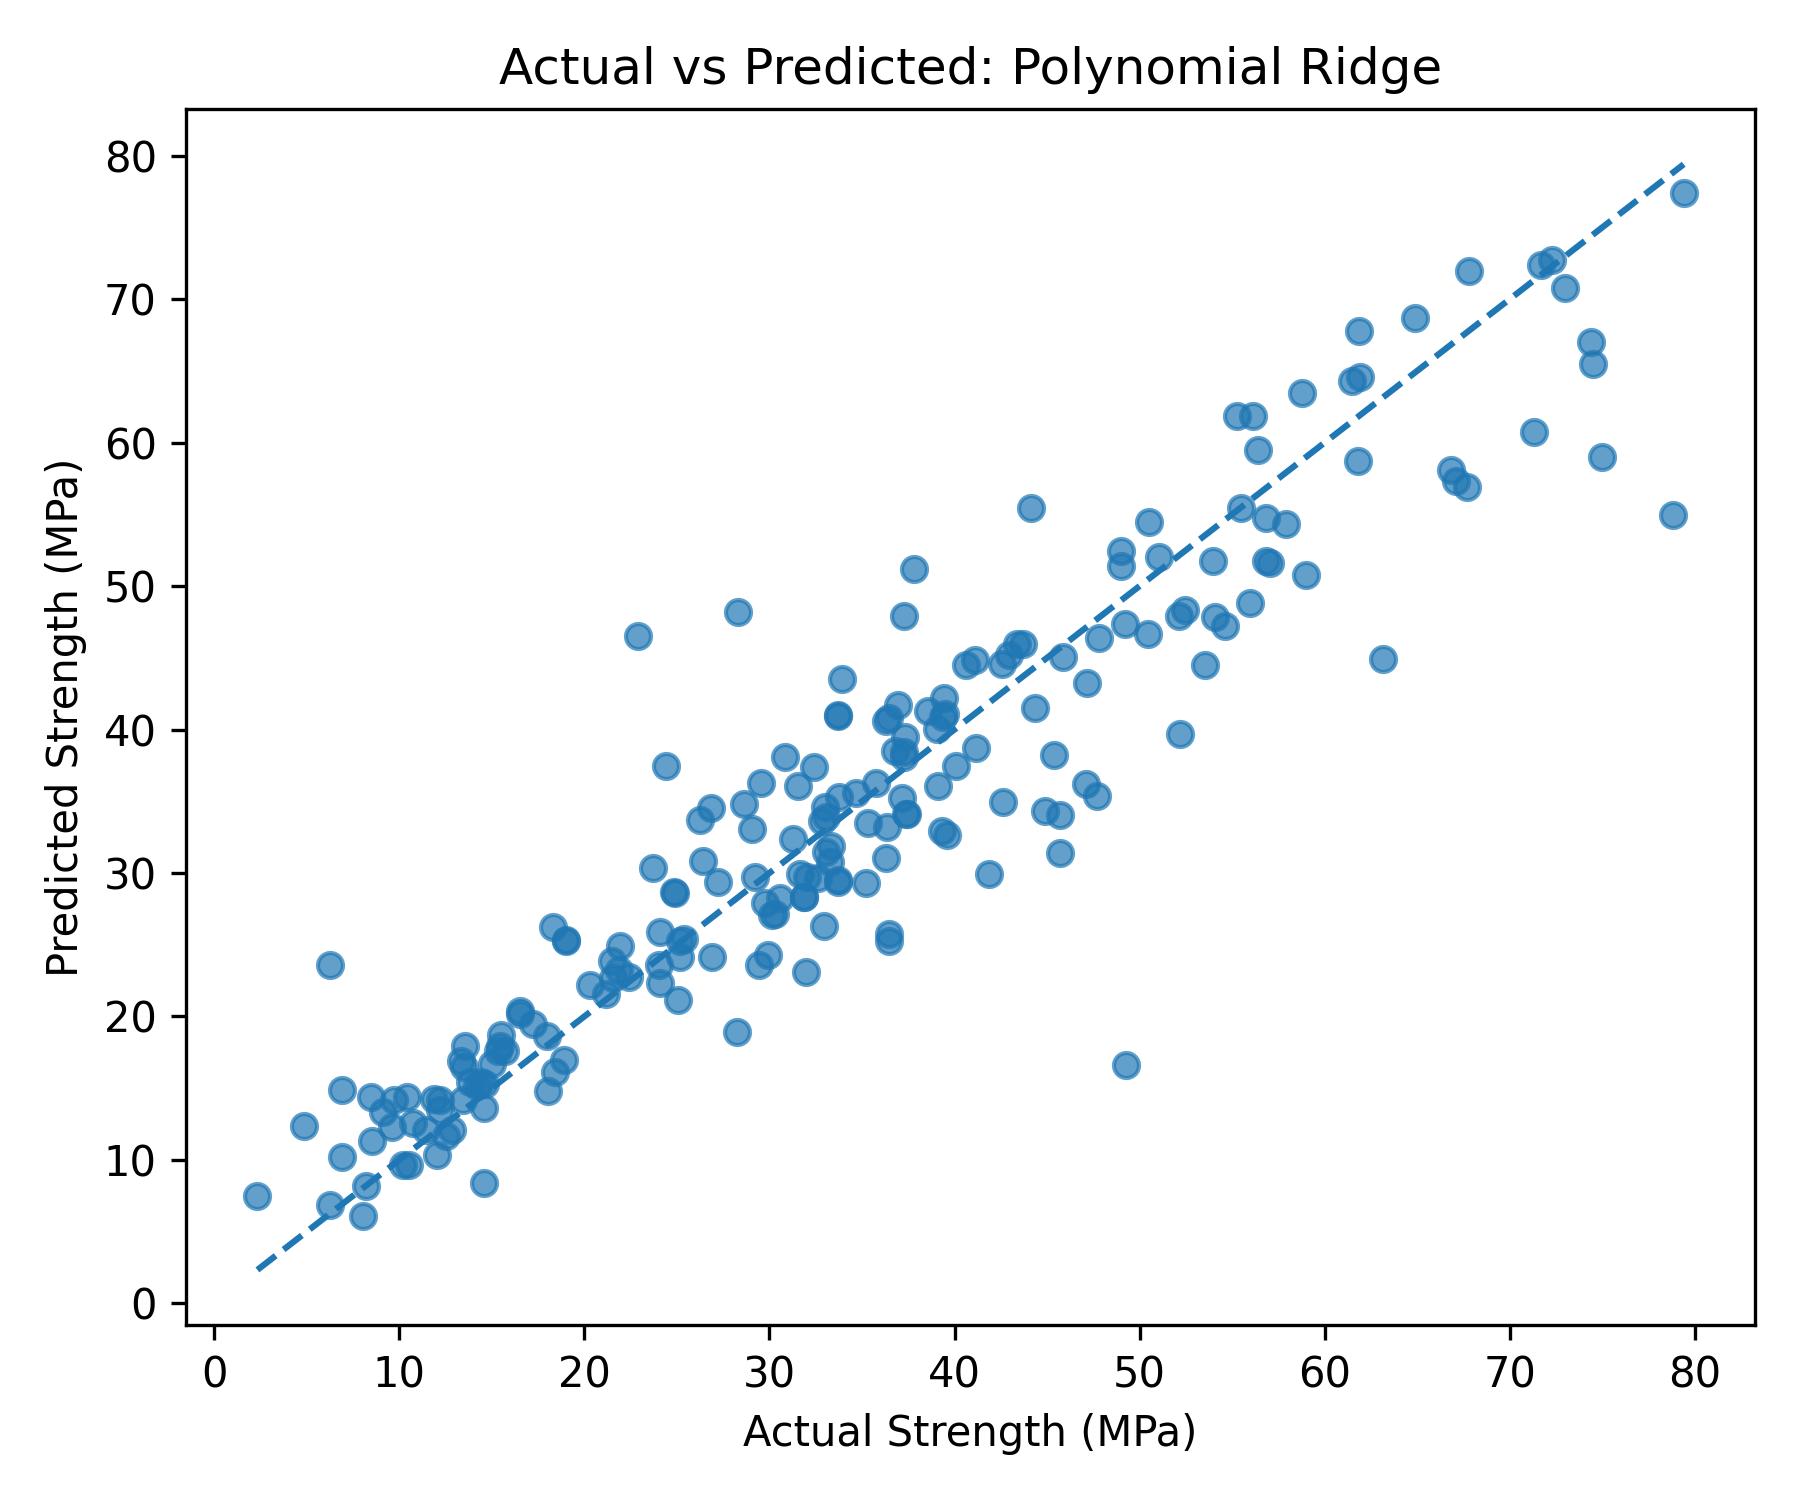

In [8]:
figure_files = sorted(FIGURES_DIR.glob('*actual_vs_predicted.png'))

if figure_files:
    for fig_path in figure_files:
        model_name = fig_path.stem.replace('_actual_vs_predicted', '').replace('_', ' ').title()
        display(Markdown(f"### {model_name}"))
        display(Image(filename=str(fig_path)))
else:
    display(Markdown(
        """
> No saved actual vs predicted figure files found.
> This is okay because figures are generated outputs and are not pushed to GitHub.
        """
    ))


## 10. Residual Analysis

Residuals are calculated as:

**residual = actual strength - predicted strength**

A good model should have residuals randomly scattered around zero.

If the residual plot shows a curve, funnel shape, or systematic pattern, then the model is missing some structure in the data:

- **Curved pattern:** The model is missing nonlinear relationships.
- **Funnel shape (increasing spread):** The model's prediction error increases with strength level.
- **Systematic bias:** Residuals are not centered at zero, indicating the model consistently over- or under-predicts.


### Bayesian Ridge

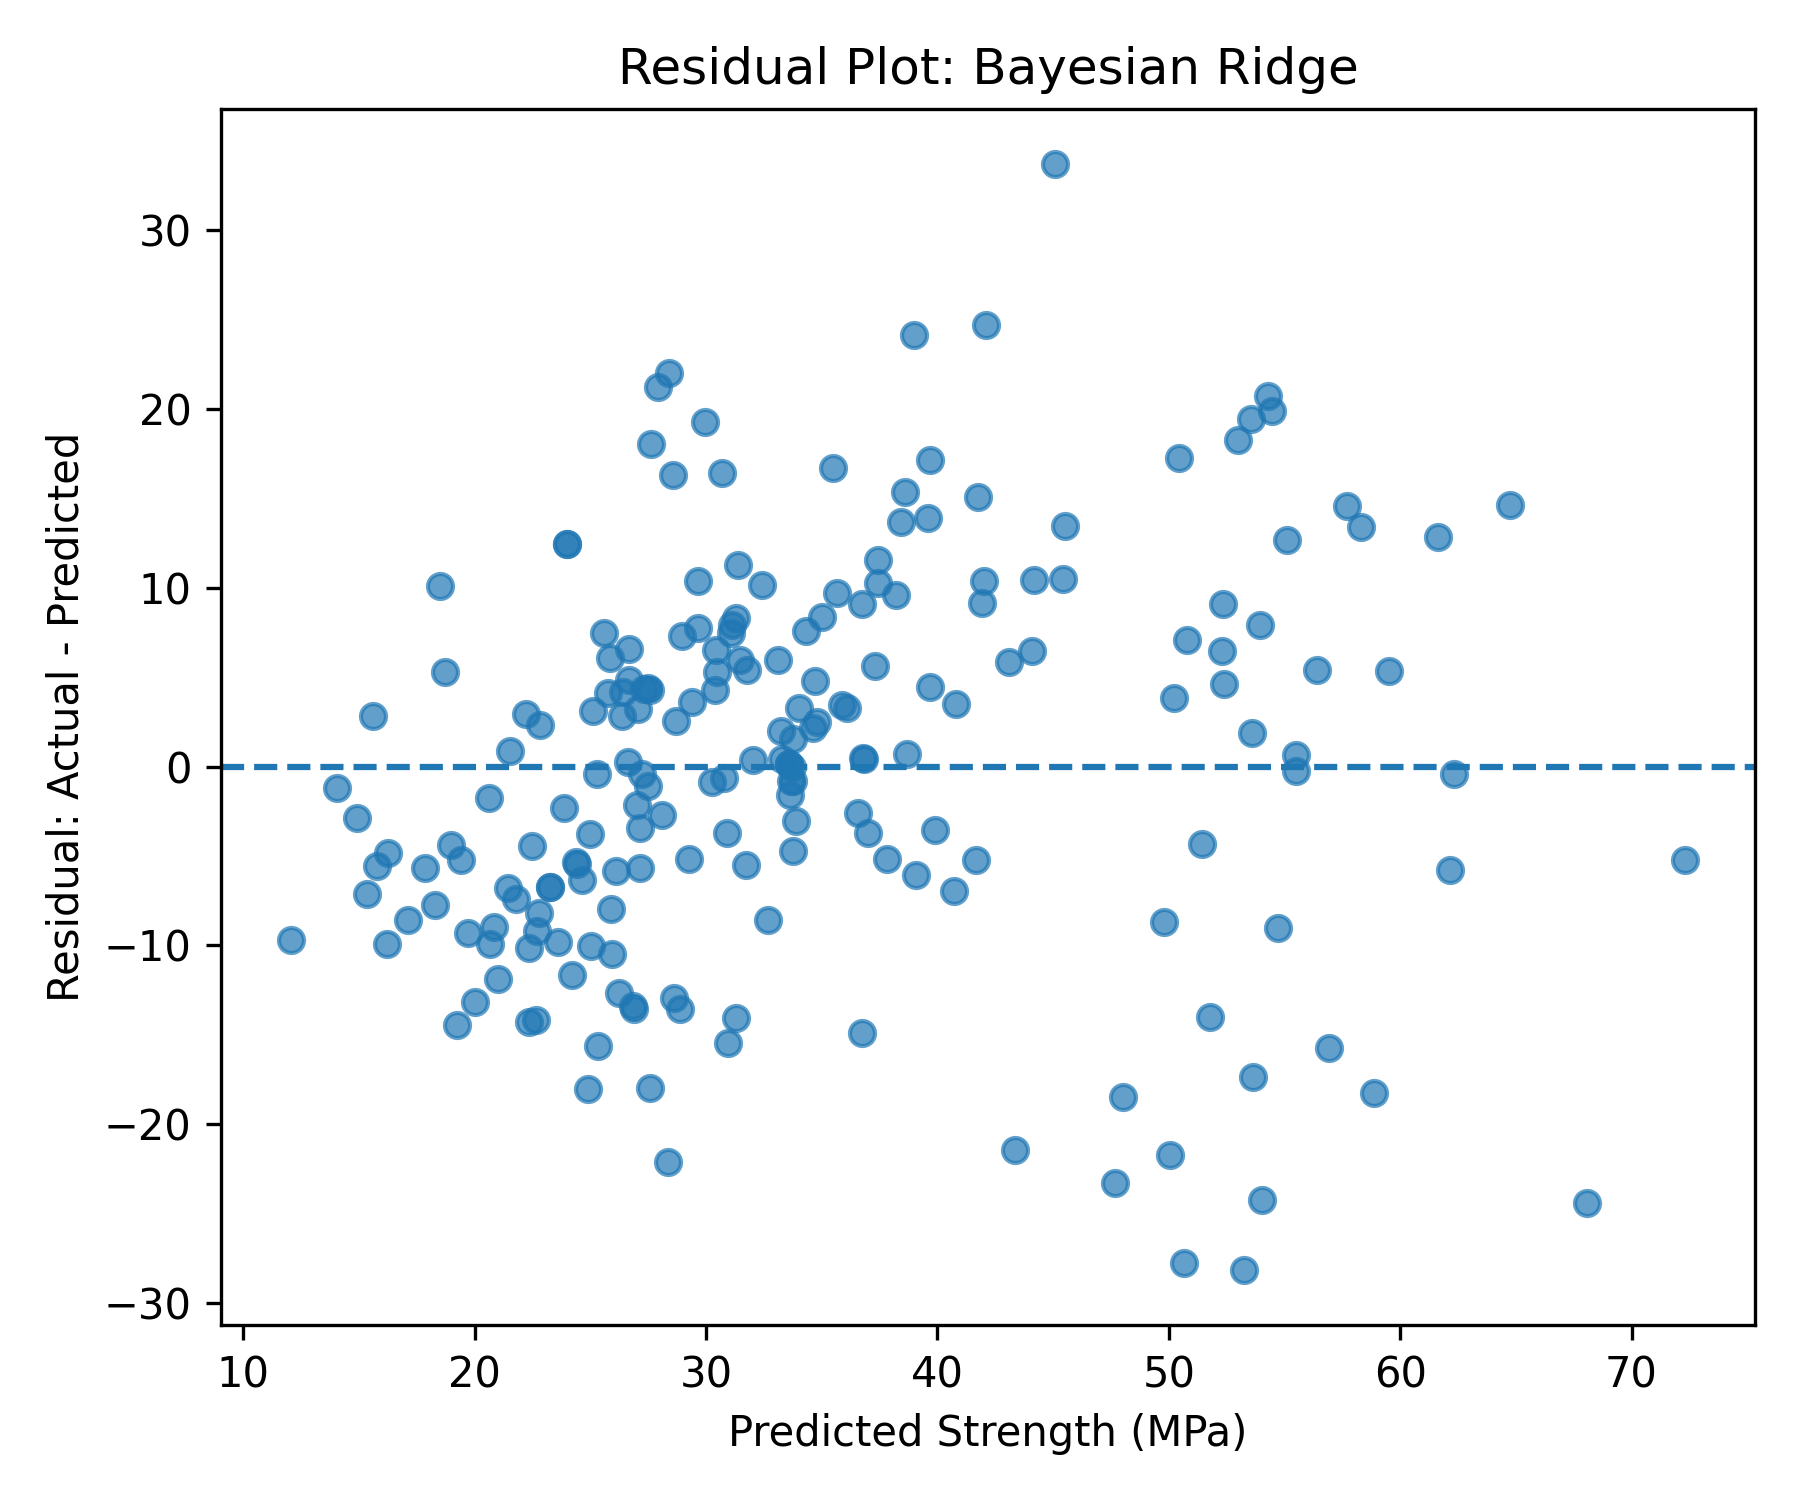

### Elastic Net

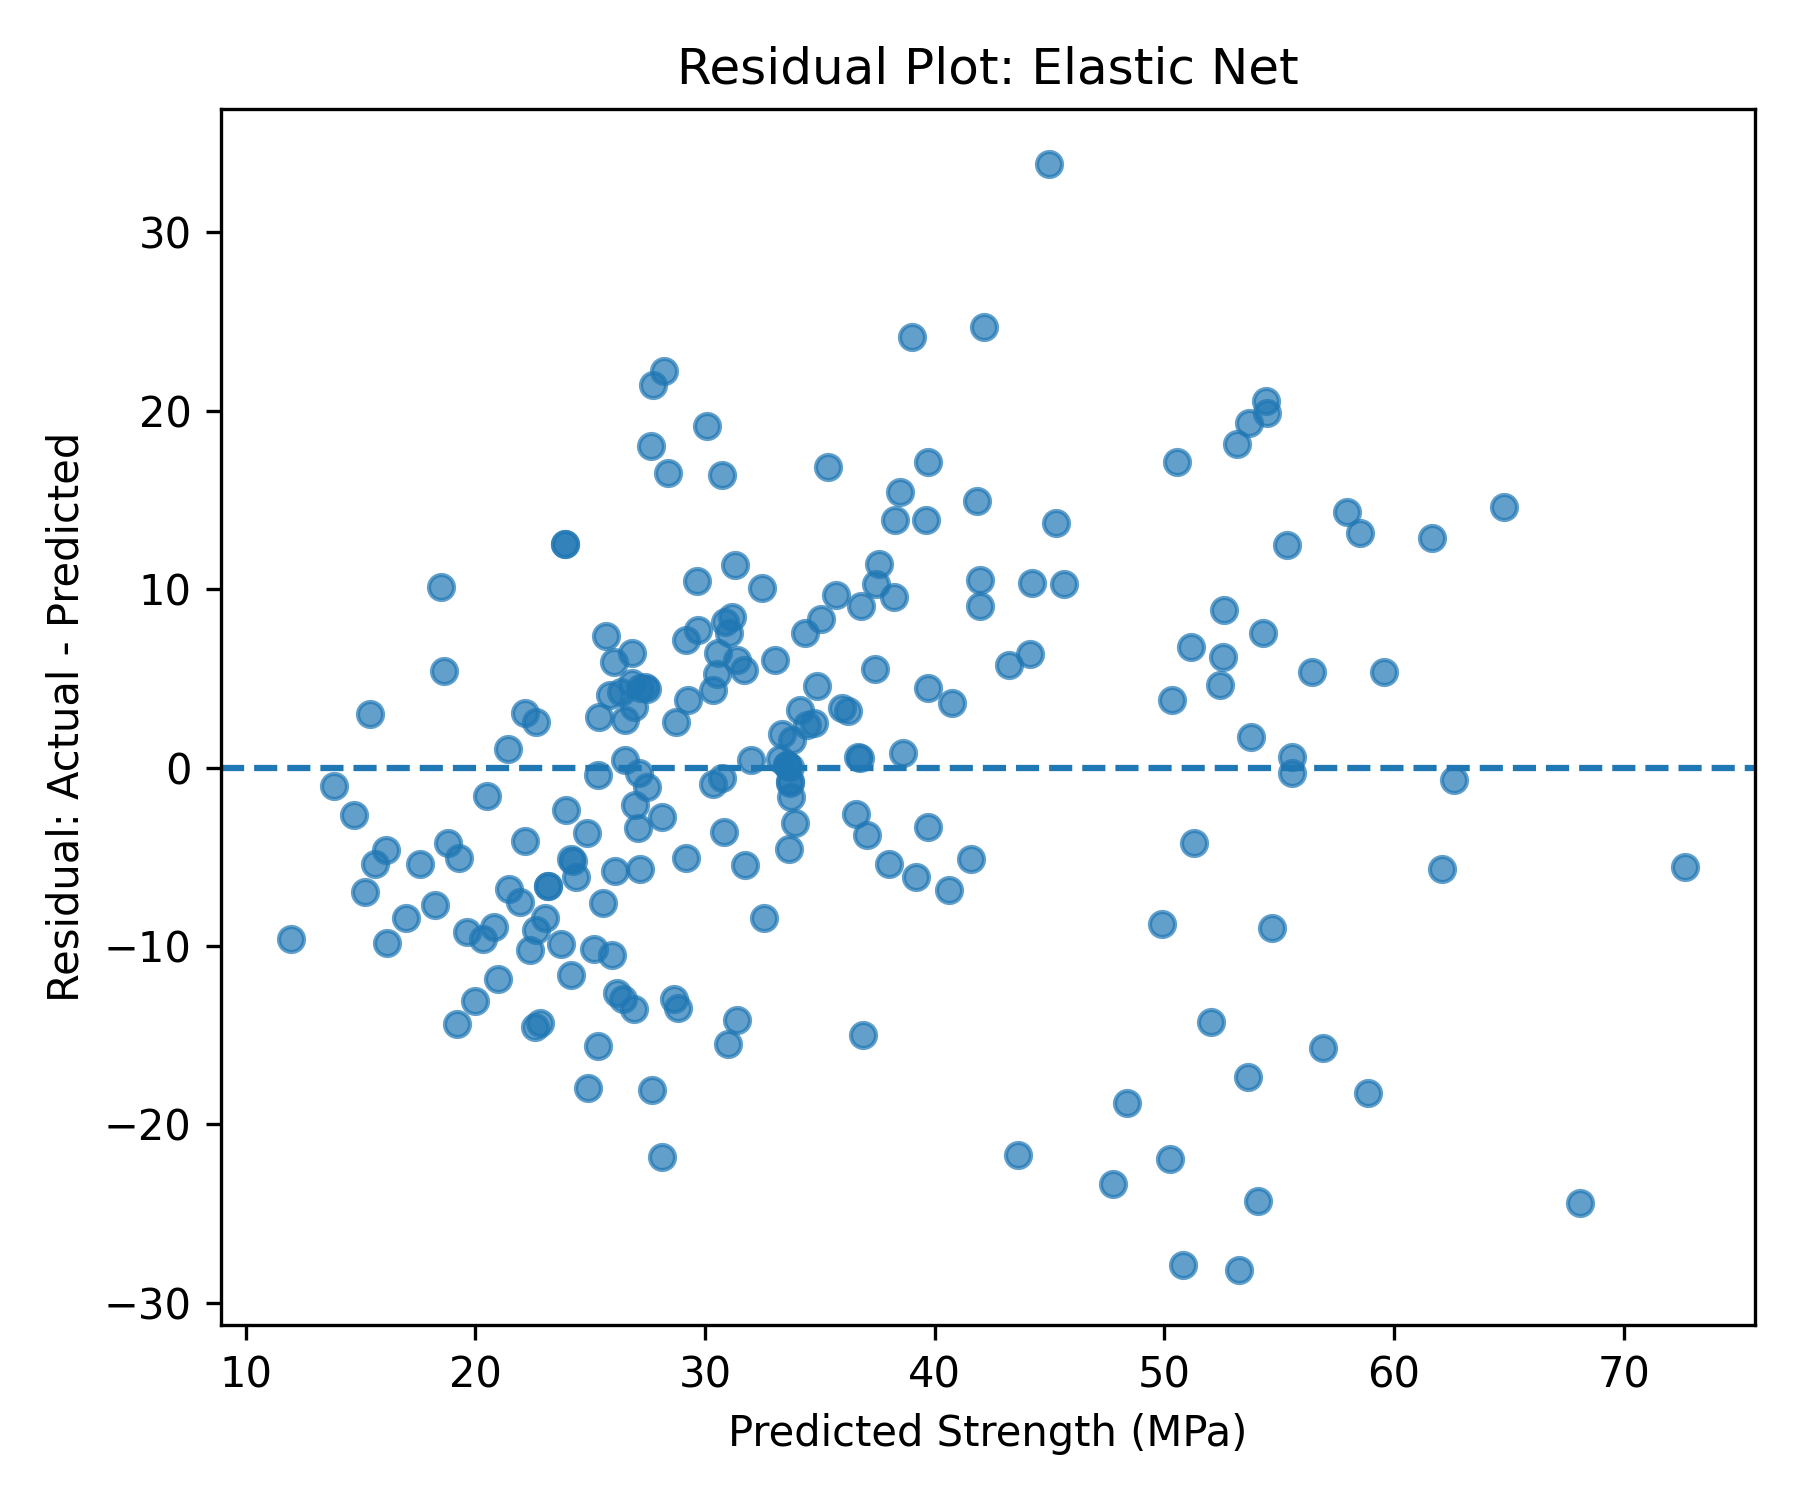

### Ols

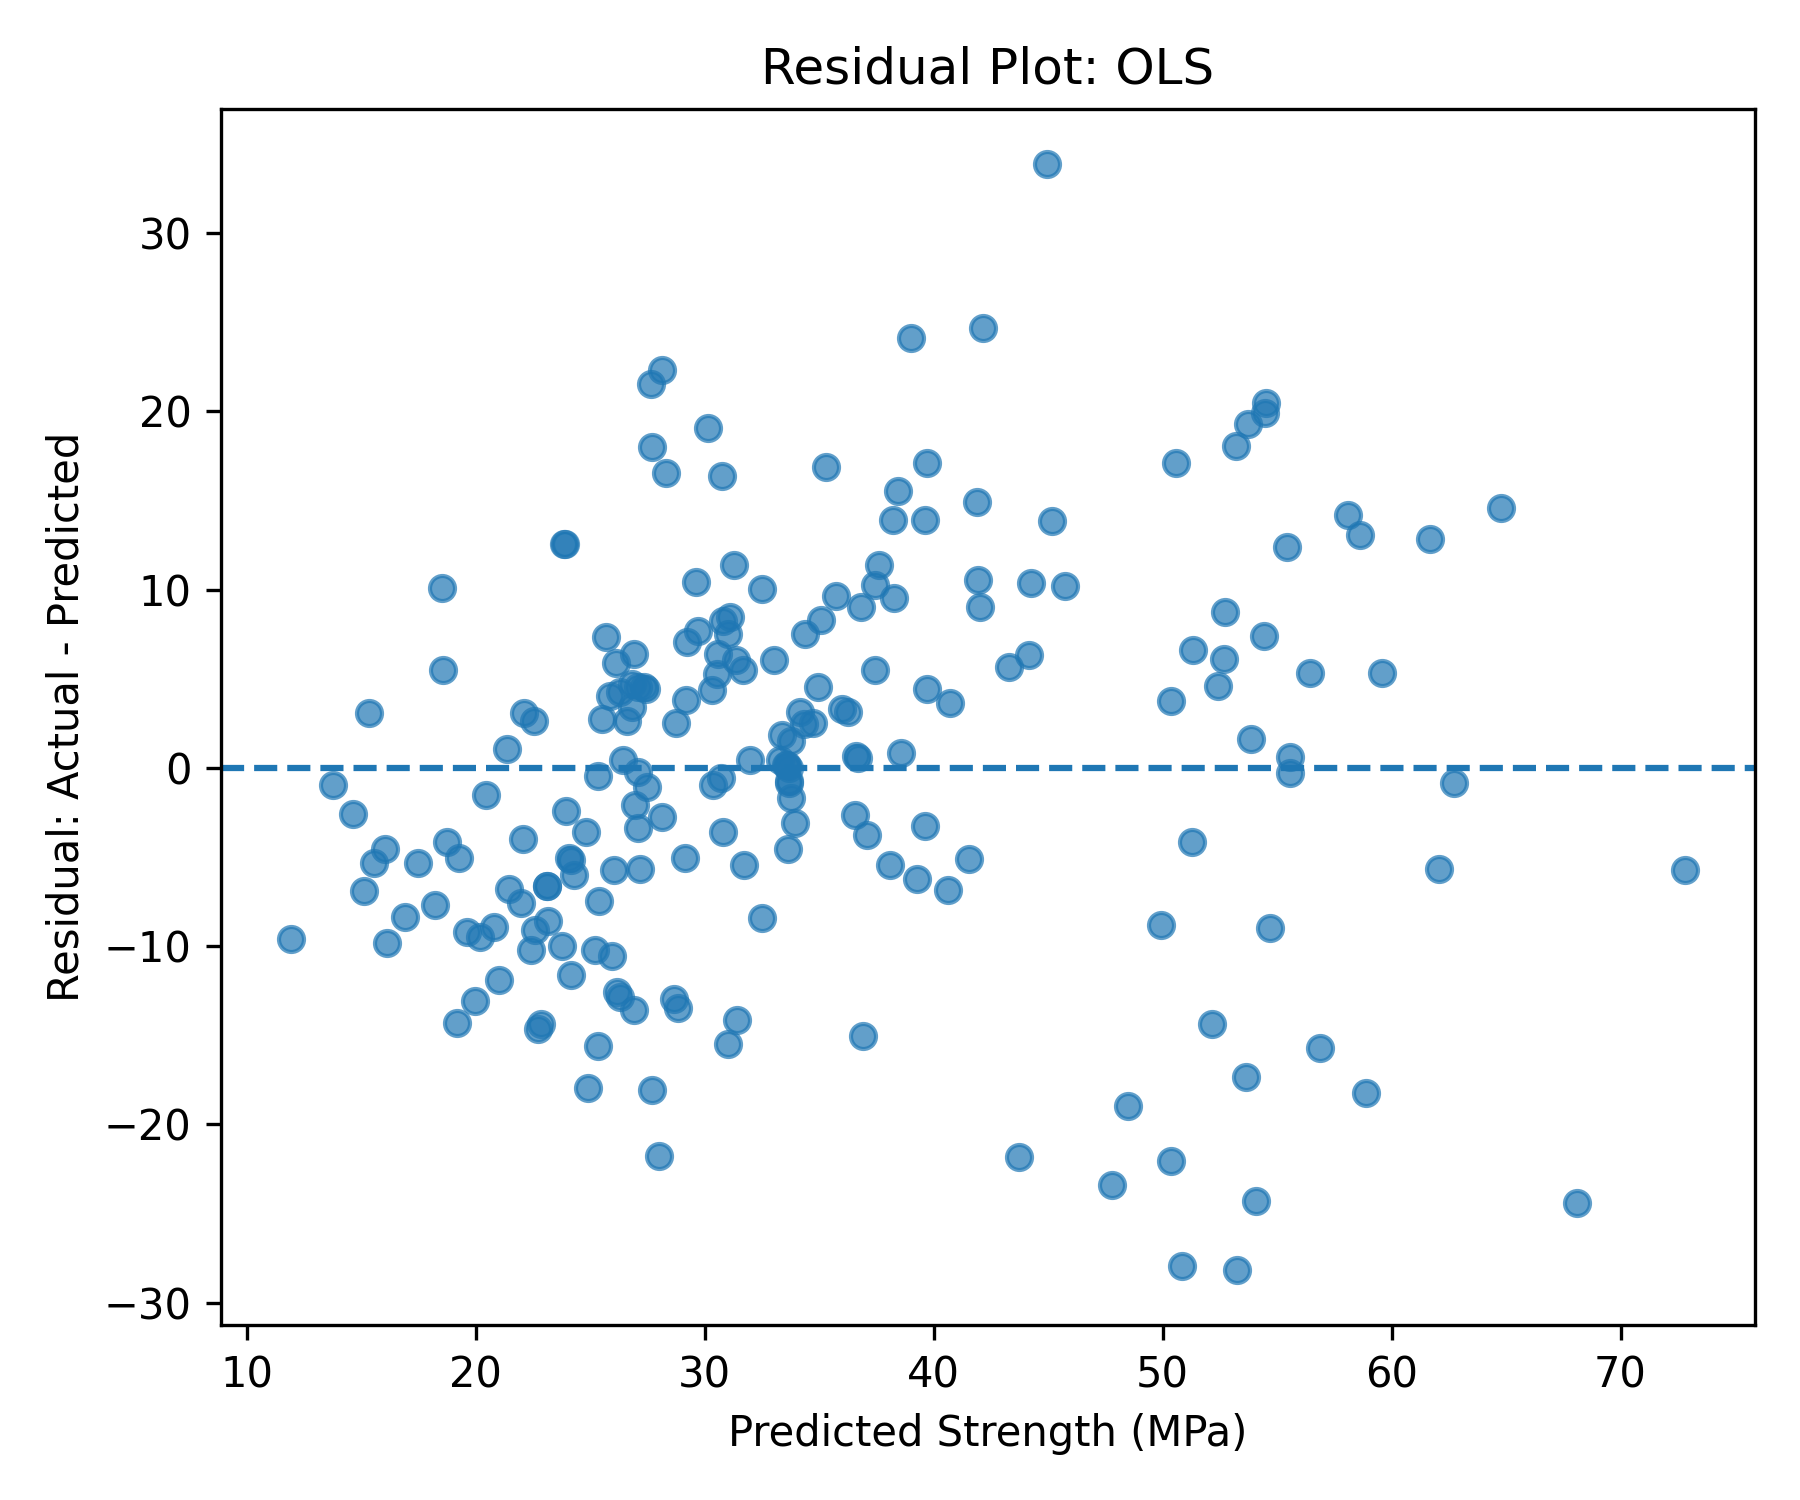

### Polynomial Ridge

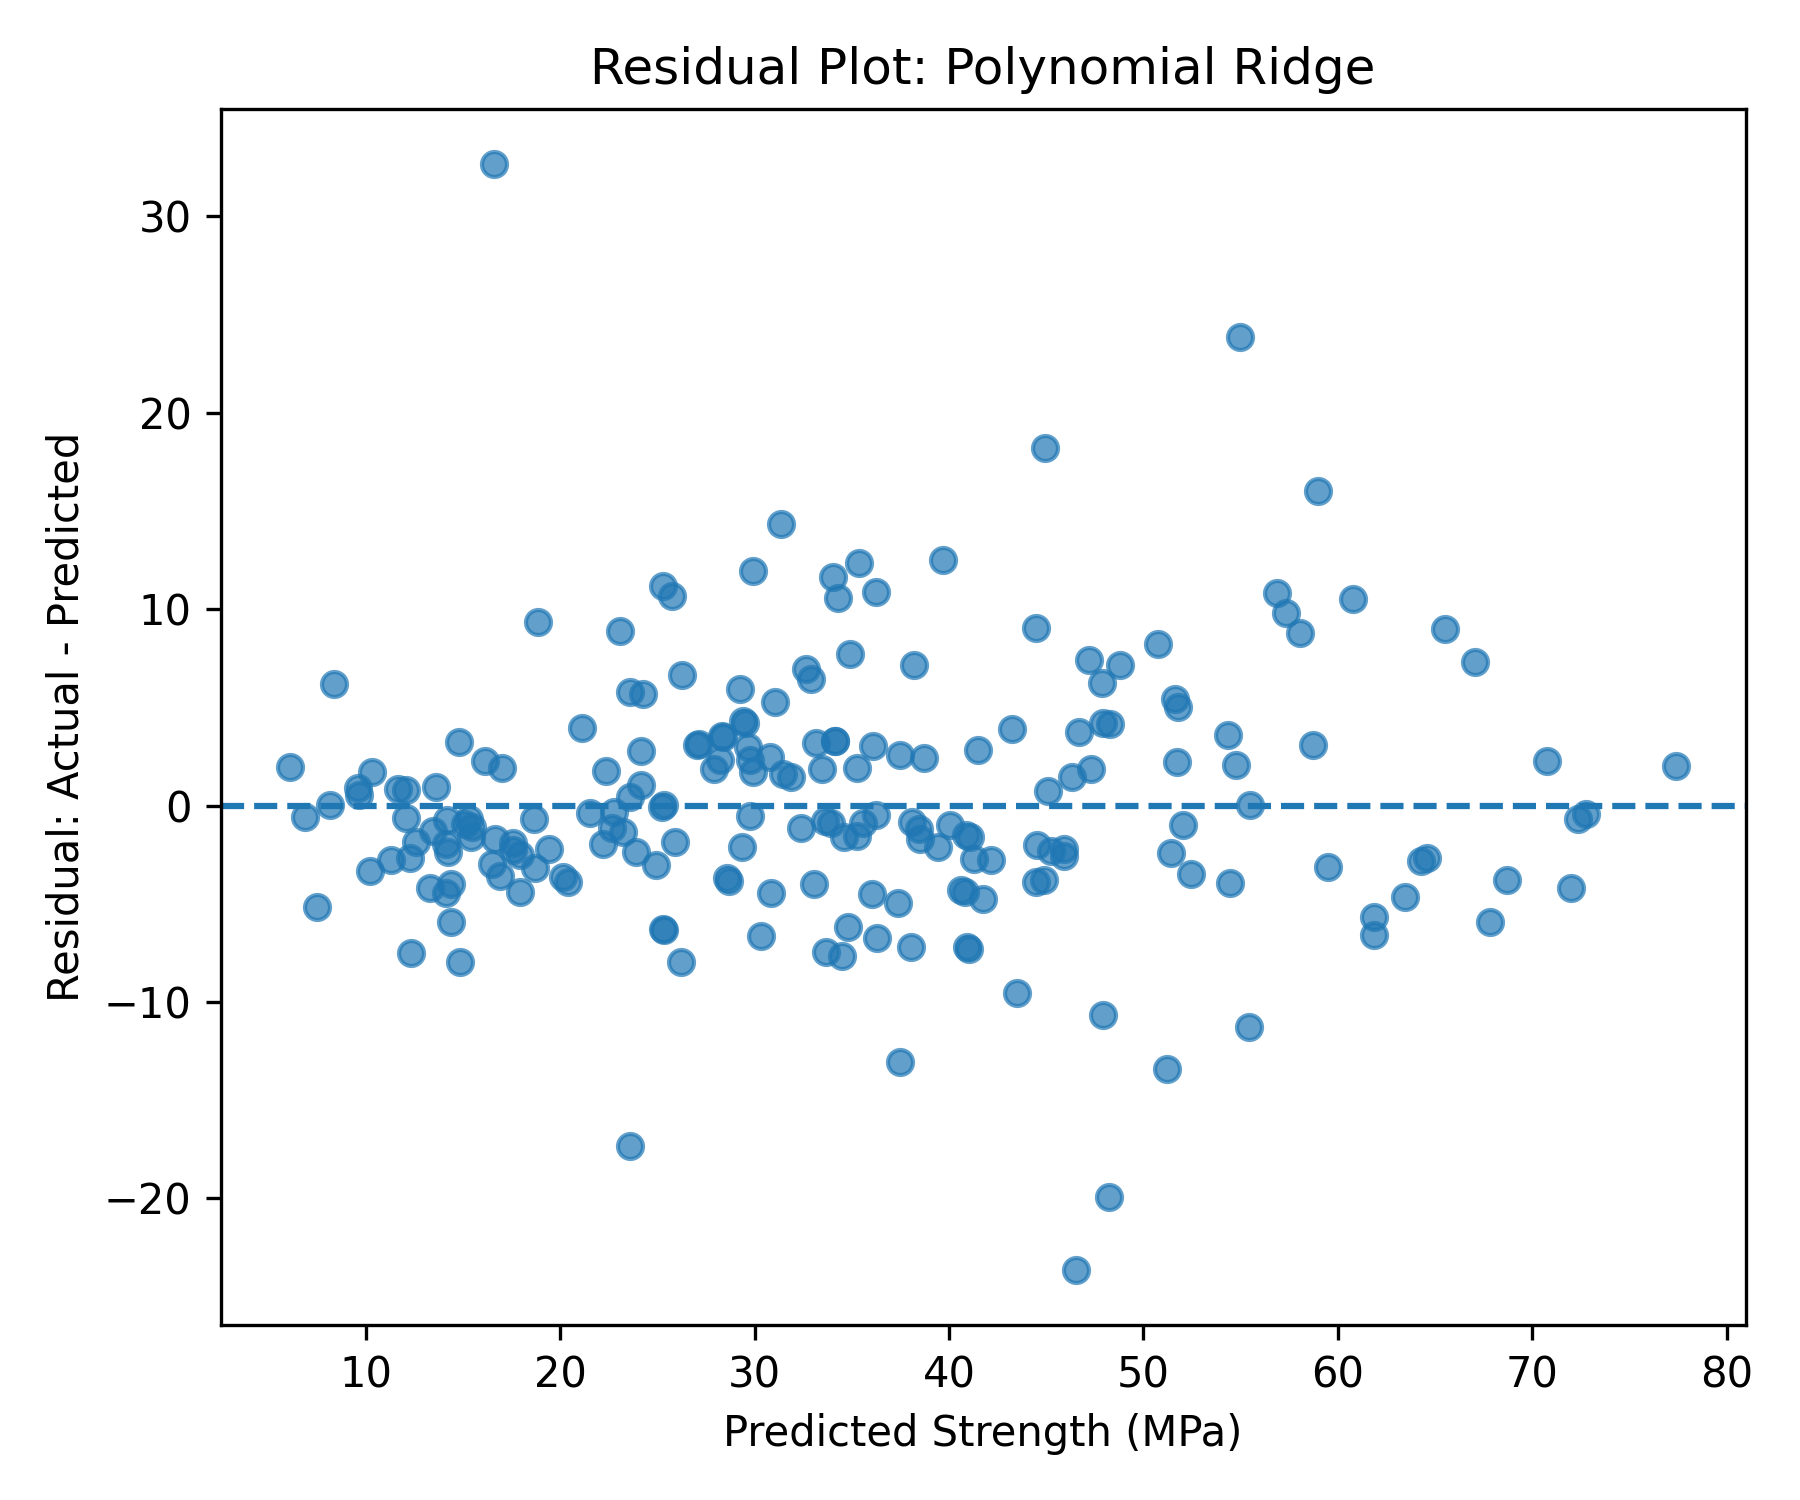

In [9]:
figure_files = sorted(FIGURES_DIR.glob('*residuals.png'))
figure_files = [f for f in figure_files if 'vs_age' not in str(f)]

if figure_files:
    for fig_path in figure_files:
        model_name = fig_path.stem.replace('_residuals', '').replace('_', ' ').title()
        display(Markdown(f"### {model_name}"))
        display(Image(filename=str(fig_path)))
else:
    display(Markdown(
        """
> No saved residual figure files found.
        """
    ))



## 11. Residuals vs Age

Age is one of the most important variables in concrete strength development.

This plot checks whether the model performs differently for early-age and late-age concrete.


### Bayesian Ridge

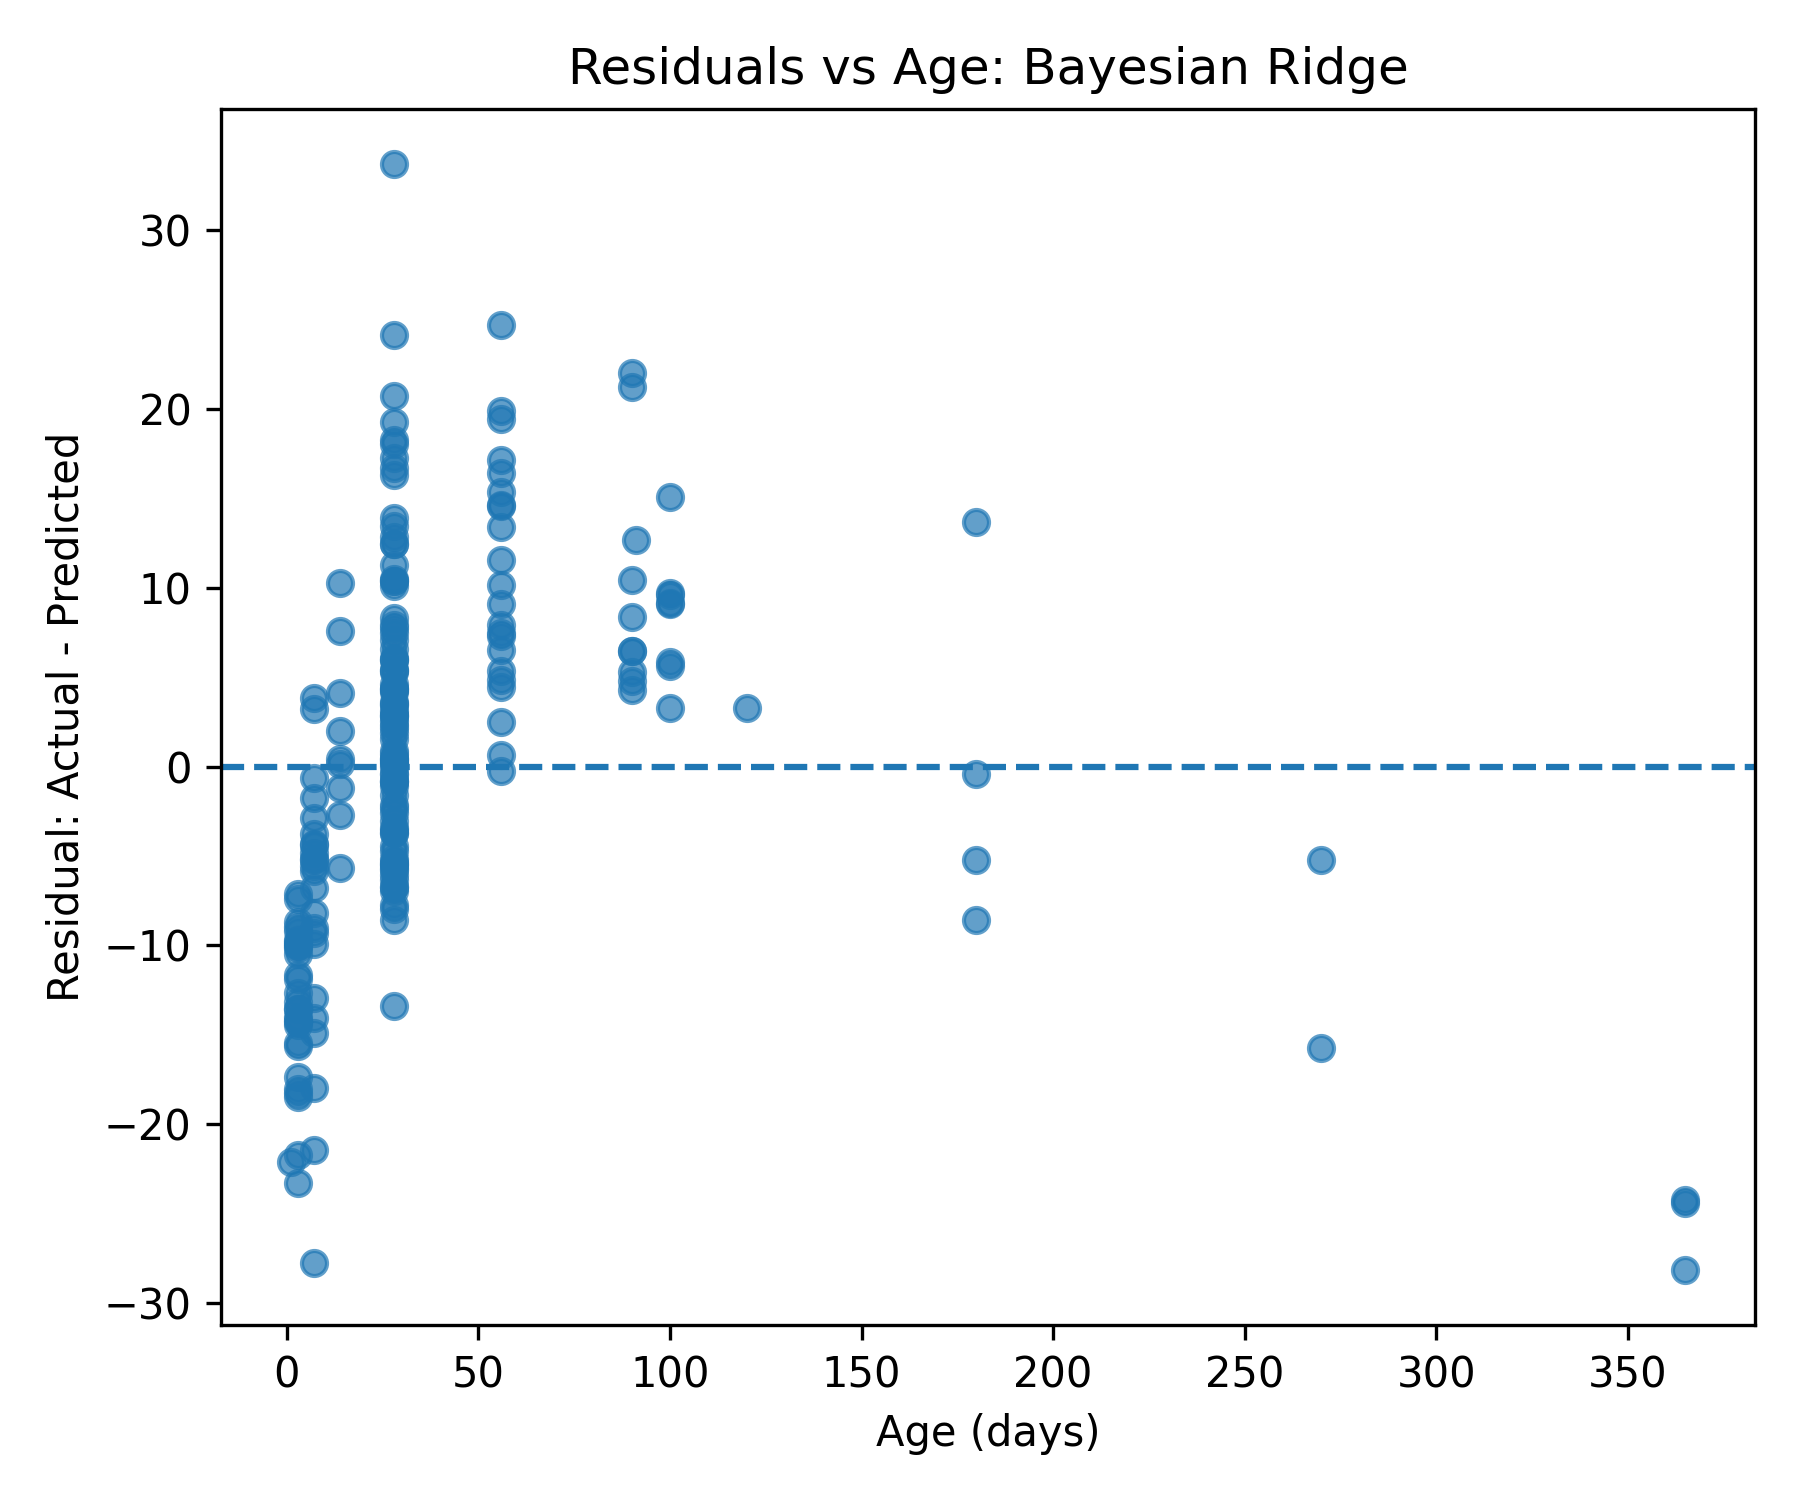

### Elastic Net

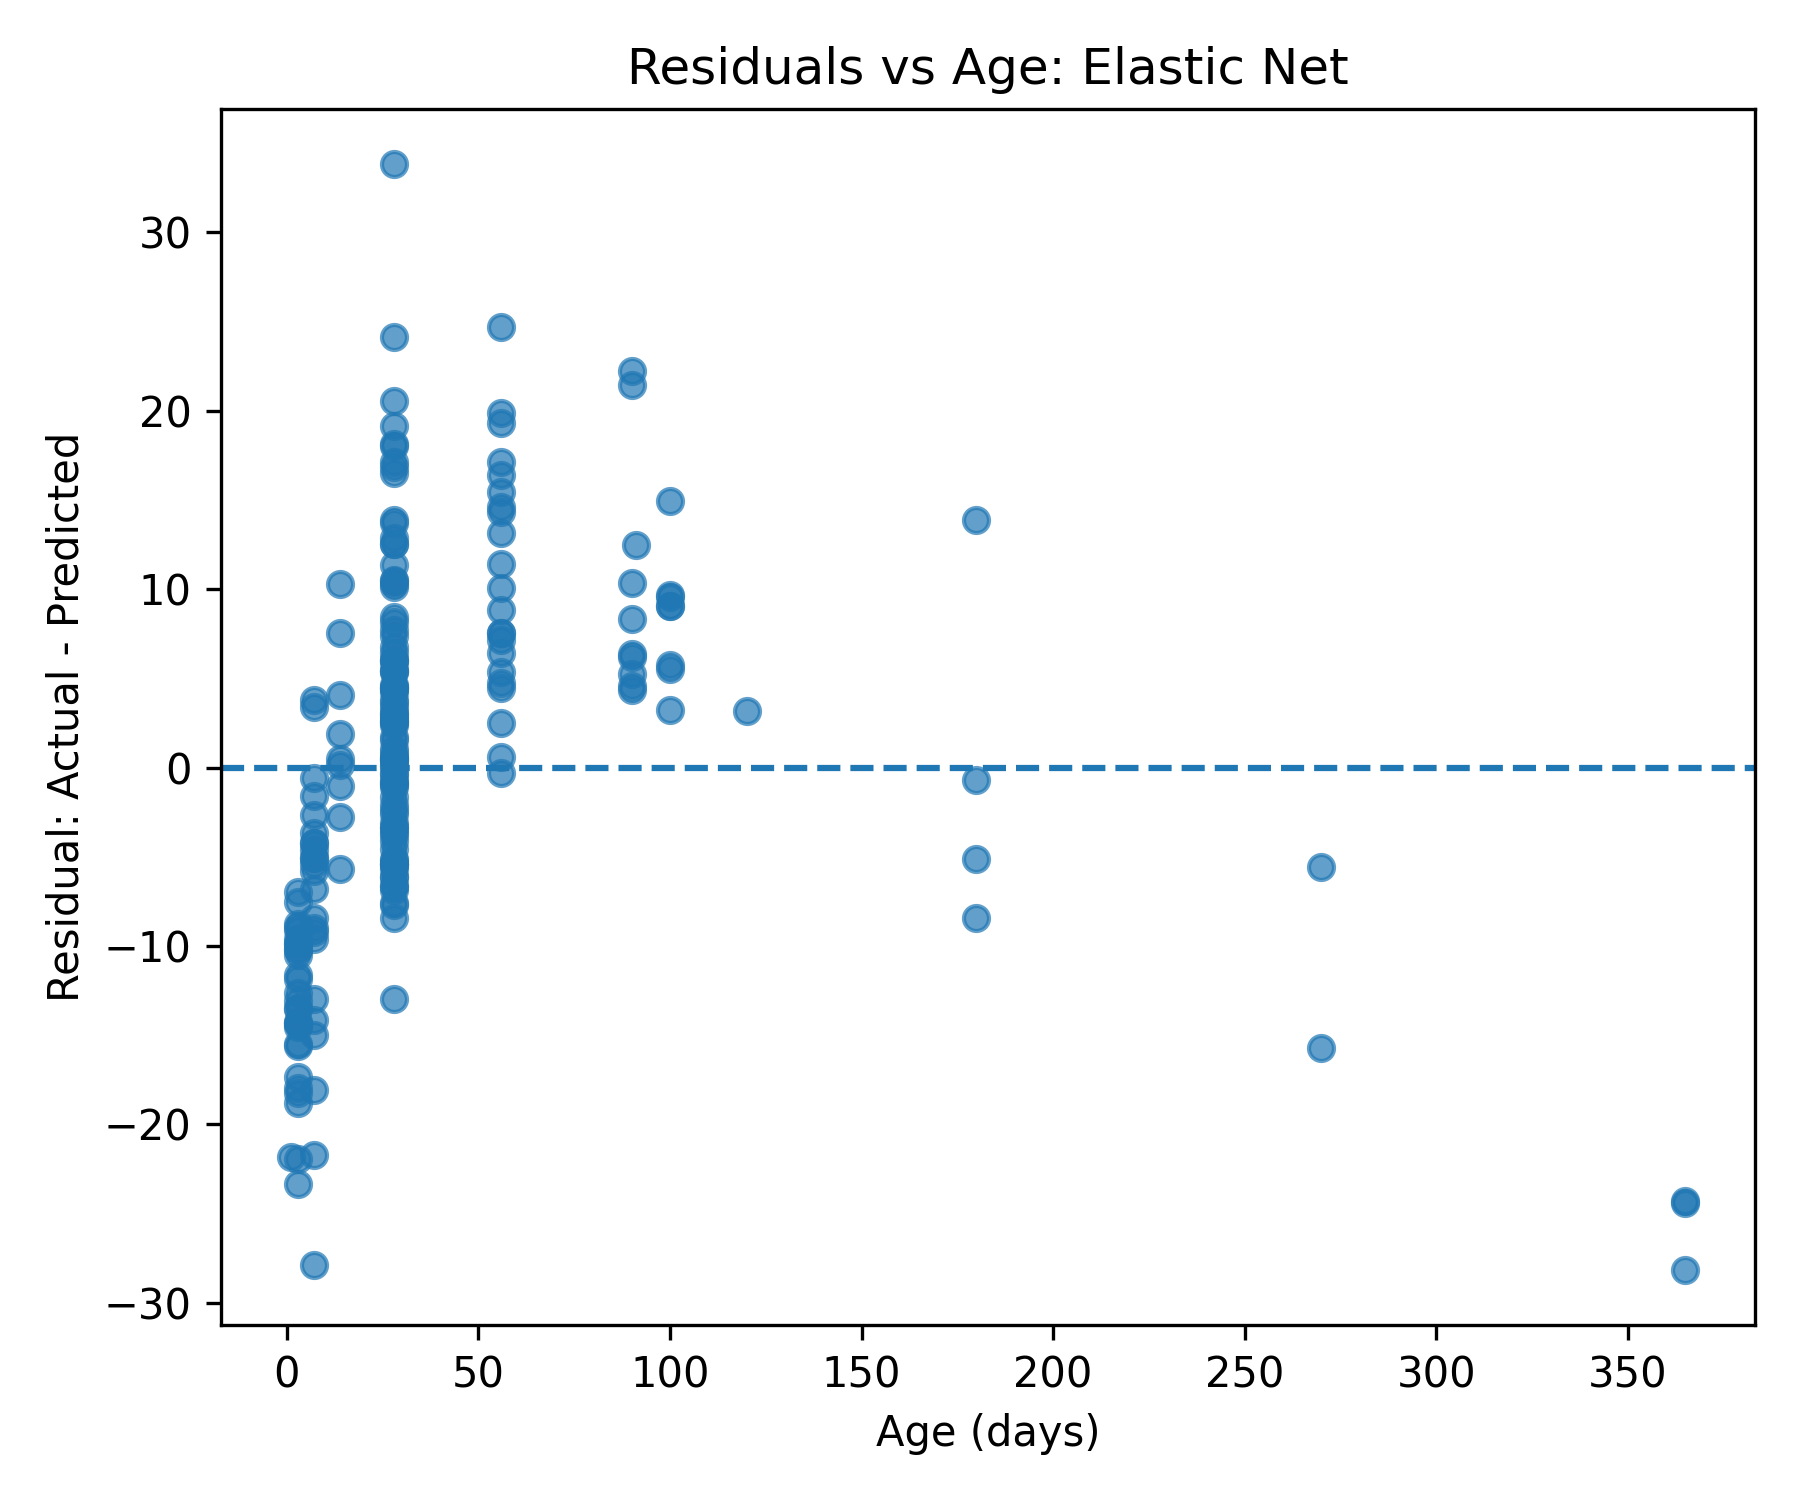

### Ols

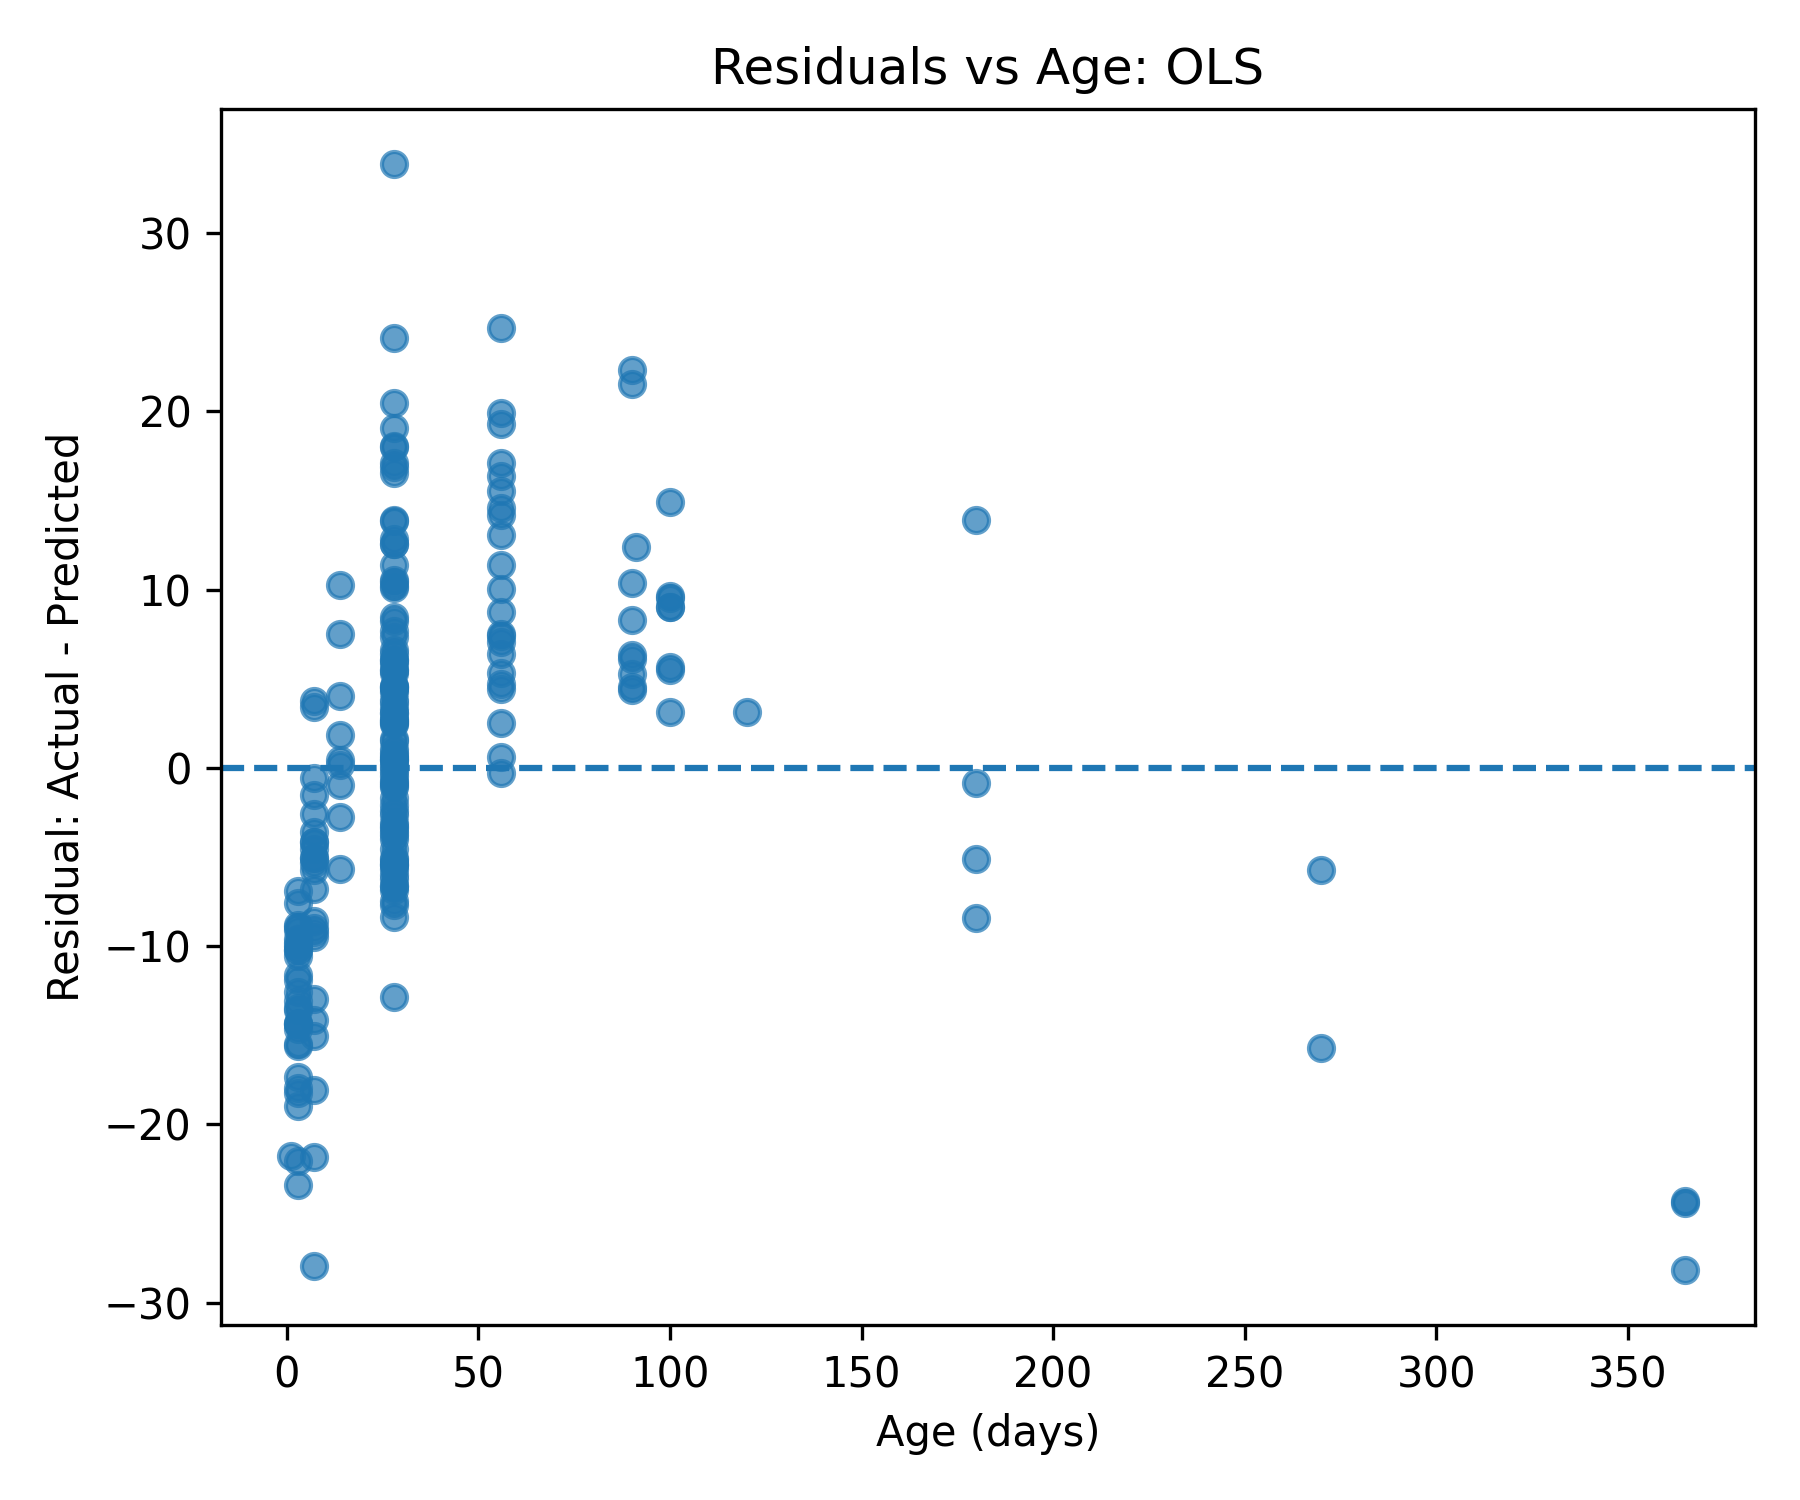

### Polynomial Ridge

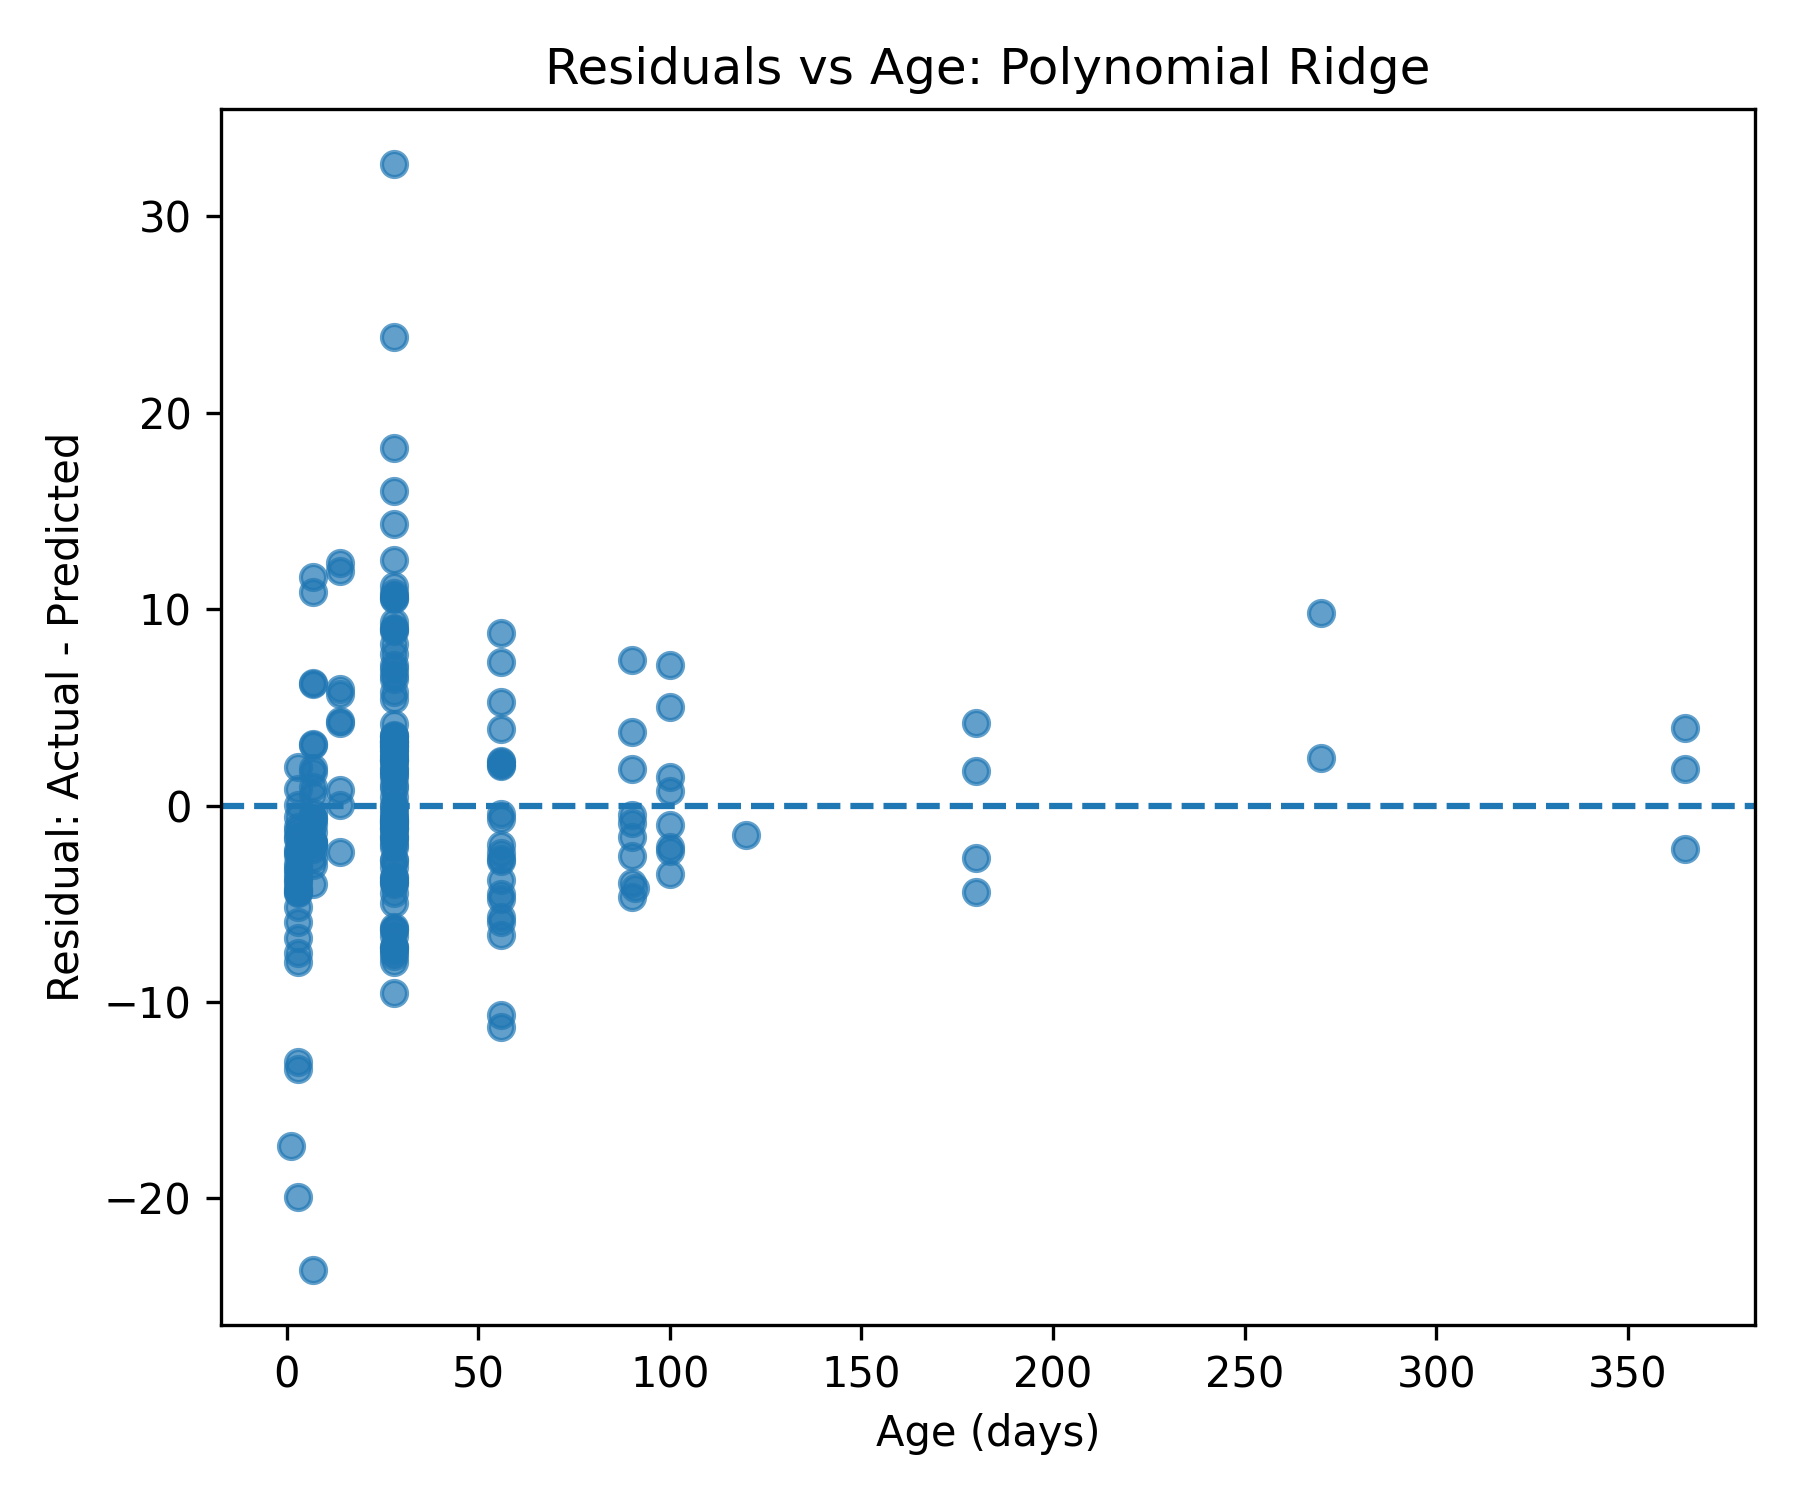

In [11]:
## 11. Residuals vs Age

display(Markdown("""
## 11. Residuals vs Age

Age is one of the most important variables in concrete strength development.

This plot checks whether the model performs differently for early-age and late-age concrete.
"""))

figure_files = sorted(FIGURES_DIR.glob('*residuals_vs_age.png'))

if figure_files:
    for fig_path in figure_files:
        model_name = fig_path.stem.replace('_residuals_vs_age', '').replace('_', ' ').title()
        display(Markdown(f"### {model_name}"))
        display(Image(filename=str(fig_path)))
else:
    display(Markdown(
        """
> No saved residuals vs age figure files found.
        """
    ))
# If residuals are larger for small ages or large ages, then the model may not capture strength development over time properly. This is important because concrete strength develops over days, months, and years, and a good model should predict accurately across all ages.


figure_files = sorted(FIGURES_DIR.glob('*residuals_vs_age.png'))

if figure_files:
    for fig_path in figure_files:
        model_name = fig_path.stem.replace('_residuals_vs_age', '').replace('_', ' ').title()
        display(Markdown(f"### {model_name}"))
        display(Image(filename=str(fig_path)))
else:
    display(Markdown(
        """
> No saved residuals vs age figure files found.
        """
    ))


## 12. Results Interpretation

The final comparison table shows the performance of all four Linear Family models.

OLS is the simplest baseline without any regularization.

Elastic Net checks whether L1/L2 regularization improves the linear model by shrinking less important coefficients.

Bayesian Ridge gives a stable regularized linear baseline where regularization strength is estimated internally.

Polynomial Ridge checks whether nonlinear polynomial terms and their interactions improve prediction accuracy.

The model with the lowest RMSE is considered the best numerical model because RMSE gives a stronger penalty to large prediction errors.

However, the best model should not be selected only from the table. The residual plots must also be checked to see whether the errors are random or systematic. If the residual plots show a clear pattern or trend, this suggests the model is missing important nonlinear relationships or interactions.


In [16]:
if metrics_df is not None:
    best = metrics_df.sort_values("RMSE").iloc[0]

## 13. Model Theory Summary

### OLS Linear Regression

OLS (Ordinary Least Squares) predicts the target as a linear combination of input features:

Strength = β₀ + β₁ Cement + β₂ Slag + ... + β₈ Age

OLS minimizes the sum of squared residuals: **Σ(y_actual - y_predicted)²**

It has no hyperparameters to tune and no regularization. It is included as the simplest baseline.

### Elastic Net

Elastic Net is a regularized linear regression model that combines L1 (Lasso) and L2 (Ridge) penalties.

It minimizes: **Squared Error + alpha × (l1_ratio × L1 + (1 - l1_ratio) × L2)**

- L1 penalty can shrink some coefficients exactly to zero, performing automatic feature selection.
- L2 penalty shrinks coefficients smoothly and helps when features are correlated.

This is useful for concrete data because mixture variables (cement, slag, fly ash, water) can be correlated, and Elastic Net can handle this.

### Bayesian Ridge

Bayesian Ridge is a probabilistic version of Ridge Regression. It applies Ridge-like L2 regularization, but the coefficients are estimated using a Bayesian approach.

In simple words: it assumes prior distributions over the model parameters and estimates regularization strength during training. It is already more adaptive than plain OLS because it estimates regularization internally.

### Polynomial Ridge Regression

Polynomial Regression extends linear regression by creating higher-order feature terms. For example, with degree 2:

**x1, x2, x1², x2², x1×x2, ...**

This is useful for concrete strength prediction because strength development is not purely linear. Age, water content, cementitious materials, and their interactions can create nonlinear behavior.

Because polynomial features increase the number of variables quickly, Ridge regularization is used after polynomial expansion to reduce overfitting.

It minimizes: **Squared Error + alpha × L2 penalty (on polynomial coefficients)**


## 15. Final Conclusion

In this Week 3 task, four Linear Family models were implemented and compared: OLS Linear Regression, Elastic Net, Bayesian Ridge, and Polynomial Ridge.

The results were loaded from the saved result files generated by the training script. The team setup uses 80/20 train-test split and 3-fold cross-validation for fair comparison.

The final models were evaluated using MAE, RMSE, R, R², and both actual-vs-predicted and residual plots. The best numerical model was selected based on RMSE, but residual plots were also used to check whether errors are random or systematic.

Overall, the Linear Family provides an interpretable baseline for concrete strength prediction. The relative performance of these models shows:

1. How much improvement regularization brings (comparing OLS, Elastic Net, Bayesian Ridge)
2. Whether polynomial nonlinearity helps (comparing Linear vs Polynomial Ridge)
3. Where improvements are still needed (through residual analysis)

If residuals show systematic patterns, this suggests that concrete strength prediction may require more complex model families in later weeks. If residuals are random and scattered, the Linear Family is already a strong baseline.
